In [ ]:
from pathlib import Path 
import json 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', 80) 
pd.set_option('display.float_format', lambda x: f'{x:,.2f}') 

# Se resuelve la ruta a los archivos desde la estructura actual del proyecto
BASE_DIR = Path.cwd()
PROJECT_ROOT = BASE_DIR.parent if BASE_DIR.name == 'code' else BASE_DIR
DATA_DIR = PROJECT_ROOT / 'data'
BASE_DIR = DATA_DIR

csv_path = DATA_DIR / 'CAvideos_cc50_202101.csv'
json_path = DATA_DIR / 'CA_category_id.json'

print('Carpeta actual:', BASE_DIR)
print('Carpeta del proyecto:', PROJECT_ROOT)
print('Carpeta de datos:', DATA_DIR)
print('Ruta CSV:', csv_path)
print('Ruta JSON:', json_path)
print('¿Existe CSV?', csv_path.exists())
print('¿Existe JSON?', json_path.exists())

Carpeta actual: c:\Users\ianla\Documentos\UPC\2026-1 - 5to Ciclo\Fundamentos Data Science\TF
Ruta CSV: c:\Users\ianla\Documentos\UPC\2026-1 - 5to Ciclo\Fundamentos Data Science\TF\CAvideos_cc50_202101.csv
Ruta JSON: c:\Users\ianla\Documentos\UPC\2026-1 - 5to Ciclo\Fundamentos Data Science\TF\CA_category_id.json
¿Existe CSV? True
¿Existe JSON? True


In [3]:
# Carga del archivo CSV y del archivo JSON 
videos = pd.read_csv(csv_path) 
with open(json_path, 'r', encoding='utf-8') as file: categories_json = json.load(file) 
print('Datos cargados correctamente.') 
print(f'Registros del CSV: {videos.shape[0]:,}') 
print(f'Columnas del CSV: {videos.shape[1]}') 
print(f'Categorías registradas en el JSON: {len(categories_json["items"])}')

Datos cargados correctamente.
Registros del CSV: 40,881
Columnas del CSV: 20
Categorías registradas en el JSON: 31


In [4]:
# Vista previa de las primeras filas del dataset original 
videos.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry
0,n1WpP7iowLc,17.14.11,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,2017-11-10T17:00:03.000Z,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/Interscope""|""Rap""",17158579,787425,43420,125882,https://i.ytimg.com/vi/n1WpP7iowLc/default.jpg,False,False,False,Eminem's new track Walk on Water ft. Beyoncé is available everywhere: http:/...,Manitoba,50.15,-96.88,POINT (-96.88332178 50.15002545)
1,0dBIkQ4Mz1M,17.14.11,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,2017-11-13T17:00:00.000Z,"plush|""bad unboxing""|""unboxing""|""fan mail""|""idubbbztv""|""idubbbztv2""|""things""...",1014651,127794,1688,13030,https://i.ytimg.com/vi/0dBIkQ4Mz1M/default.jpg,False,False,False,STill got a lot of packages. Probably will last for another year. On a side ...,British Columbia,49.10,-116.52,POINT (-116.516697 49.09996035)
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Lele Pons",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""|""racist""|""superman""|""love""|""r...",3191434,146035,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► https://www.youtube.com/channel/UC...,New Brunswick,45.27,-66.08,POINT (-66.07667505000001 45.26704185)
3,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""idy""|""rhpc""|""dares""|""no truth""...",2095828,132239,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,"I know it's been a while since we did this show, but we're back with what mi...",Saskatchewan,50.93,-102.80,POINT (-102.7999891 50.93331097)
4,2Vv-BfVoq4g,17.14.11,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,2017-11-09T11:04:14.000Z,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cover""|""official""|""remix""|""officia...",33523622,1634130,21082,85067,https://i.ytimg.com/vi/2Vv-BfVoq4g/default.jpg,False,False,False,🎧: https://ad.gt/yt-perfect\n💰: https://atlanti.cr/yt-album\nSubscribe to Ed...,Alberta,53.02,-112.82,POINT (-112.8166386 53.01669802)


In [5]:
# Lista de columnas disponibles en el dataset 
columnas = pd.DataFrame({ 'N°': range(1, len(videos.columns) + 1), 'Columna': videos.columns }) 
columnas

,N°,Columna
0,1,video_id
1,2,trending_date
2,3,title
3,4,channel_title
4,5,category_id
5,6,publish_time
6,7,tags
7,8,views
8,9,likes
9,10,dislikes


In [6]:
# Conversión del archivo JSON a una tabla de categorías 
categories = pd.DataFrame([ 
    { 'category_id': int(item['id']), 
     'category_title': item['snippet']['title'], 
     'assignable': item['snippet']['assignable'] 
    } 
    for item in categories_json['items'] 
]) 
categories.head(10)

,category_id,category_title,assignable
0,1,Film & Animation,True
1,2,Autos & Vehicles,True
2,10,Music,True
3,15,Pets & Animals,True
4,17,Sports,True
5,18,Short Movies,False
6,19,Travel & Events,True
7,20,Gaming,True
8,21,Videoblogging,False
9,22,People & Blogs,True


In [7]:
# Integración del CSV con el JSON de categorías 
# Esta condición evita duplicar columnas si se ejecuta la celda más de una vez 
if 'category_title' in videos.columns: 
    videos = videos.drop(columns=['category_title']) 

videos = videos.merge( 
    categories[['category_id', 'category_title']], 
    on='category_id', 
    how='left' ) 

videos[['category_id', 'category_title', 'title', 'channel_title']].head(10)

,category_id,category_title,title,channel_title
0,10,Music,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO
1,23,Comedy,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV
2,23,Comedy,"Racist Superman | Rudy Mancuso, King Bach & Lele Pons",Rudy Mancuso
3,24,Entertainment,I Dare You: GOING BALD!?,nigahiga
4,10,Music,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran
5,25,News & Politics,Jake Paul Says Alissa Violet CHEATED with LOGAN PAUL! #DramaAlert Team 10 vs...,DramaAlert
6,23,Comedy,Vanoss Superhero School - New Students,VanossGaming
7,22,People & Blogs,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat
8,24,Entertainment,THE LOGANG MADE HISTORY. LOL. AGAIN.,Logan Paul Vlogs
9,22,People & Blogs,Finally Sheldon is winning an argument about the existence of God,Sheikh Musa


In [8]:
# Diccionario de datos del proyecto 
diccionario_datos = pd.DataFrame([ 
    ['video_id', 'Texto', 'Identificador único del video en YouTube.', 'Permite reconocer videos repetidos.'], 
    ['trending_date', 'Fecha', 'Fecha en la que el video apareció como tendencia.', 'Análisis temporal.'], 
    ['title', 'Texto', 'Título del video.', 'Descripción del contenido.'], 
    ['channel_title', 'Texto', 'Canal que publicó el video.', 'Análisis de canales frecuentes.'], 
    ['category_id', 'Numérico', 'Código de categoría del video.', 'Se une con el JSON de categorías.'], 
    ['category_title', 'Texto', 'Nombre de la categoría del video.', 'Análisis por categoría.'], 
    ['publish_time', 'Fecha-hora', 'Fecha y hora de publicación.', 'Cálculo de días hasta tendencia.'], 
    ['tags', 'Texto', 'Etiquetas del video.', 'Análisis descriptivo o creación de variables.'], 
    ['views', 'Numérico', 'Número de vistas.', 'Variable dependiente propuesta.'], 
    ['likes', 'Numérico', 'Cantidad de Me gusta.', 'Indicador de aceptación.'], 
    ['dislikes', 'Numérico', 'Cantidad de No me gusta.', 'Indicador de rechazo.'], 
    ['comment_count', 'Numérico', 'Cantidad de comentarios.', 'Indicador de interacción.'], 
    ['thumbnail_link', 'Texto', 'Enlace de miniatura del video.', 'Variable descriptiva no prioritaria.'], 
    ['comments_disabled', 'Booleano', 'Indica si los comentarios están desactivados.', 'Control de calidad.'], 
    ['ratings_disabled', 'Booleano', 'Indica si las valoraciones están desactivadas.', 'Control de calidad.'], 
    ['video_error_or_removed', 'Booleano', 'Indica si el video tiene error o fue removido.', 'Control de calidad.'], 
    ['description', 'Texto', 'Descripción del video.', 'Puede tener valores faltantes.'], 
    ['state', 'Texto', 'Estado asociado al registro.', 'Análisis geográfico.'], 
    ['lat', 'Numérico', 'Latitud del estado.', 'Visualización geográfica.'], 
    ['lon', 'Numérico', 'Longitud del estado.', 'Visualización geográfica.'], 
    ['geometry', 'Texto geográfico', 'Coordenadas geográficas.', 'Posible uso en mapas.'] ], 
    
    columns=['Columna', 'Tipo esperado', 'Descripción', 'Uso en el proyecto']) 

diccionario_datos

,Columna,Tipo esperado,Descripción,Uso en el proyecto
0,video_id,Texto,Identificador único del video en YouTube.,Permite reconocer videos repetidos.
1,trending_date,Fecha,Fecha en la que el video apareció como tendencia.,Análisis temporal.
2,title,Texto,Título del video.,Descripción del contenido.
3,channel_title,Texto,Canal que publicó el video.,Análisis de canales frecuentes.
4,category_id,Numérico,Código de categoría del video.,Se une con el JSON de categorías.
5,category_title,Texto,Nombre de la categoría del video.,Análisis por categoría.
6,publish_time,Fecha-hora,Fecha y hora de publicación.,Cálculo de días hasta tendencia.
7,tags,Texto,Etiquetas del video.,Análisis descriptivo o creación de variables.
8,views,Numérico,Número de vistas.,Variable dependiente propuesta.
9,likes,Numérico,Cantidad de Me gusta.,Indicador de aceptación.


In [9]:
# Resumen de tipos de datos detectados por Python 
tipos_detectados = pd.DataFrame({ 
    'Columna': videos.columns, 
    'Tipo detectado por Python': videos.dtypes.astype(str).values 
}) 

tipos_detectados

,Columna,Tipo detectado por Python
0,video_id,object
1,trending_date,object
2,title,object
3,channel_title,object
4,category_id,int64
5,publish_time,object
6,tags,object
7,views,int64
8,likes,int64
9,dislikes,int64


In [10]:
# Información general del dataset 
videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40881 entries, 0 to 40880
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                40881 non-null  object 
 1   trending_date           40881 non-null  object 
 2   title                   40881 non-null  object 
 3   channel_title           40881 non-null  object 
 4   category_id             40881 non-null  int64  
 5   publish_time            40881 non-null  object 
 6   tags                    40881 non-null  object 
 7   views                   40881 non-null  int64  
 8   likes                   40881 non-null  int64  
 9   dislikes                40881 non-null  int64  
 10  comment_count           40881 non-null  int64  
 11  thumbnail_link          40881 non-null  object 
 12  comments_disabled       40881 non-null  bool   
 13  ratings_disabled        40881 non-null  bool   
 14  video_error_or_removed  40881 non-null

In [11]:
# Tabla de inspección general 
inspeccion = pd.DataFrame({ 
    'columna': videos.columns, 
    'tipo_dato': videos.dtypes.astype(str).values, 
    'valores_no_nulos': videos.notnull().sum().values, 
    'valores_nulos': videos.isnull().sum().values, 
    'valores_unicos': videos.nunique().values }) 

inspeccion

,columna,tipo_dato,valores_no_nulos,valores_nulos,valores_unicos
0,video_id,object,40881,0,24427
1,trending_date,object,40881,0,205
2,title,object,40881,0,24573
3,channel_title,object,40881,0,5076
4,category_id,int64,40881,0,17
5,publish_time,object,40881,0,23613
6,tags,object,40881,0,20157
7,views,int64,40881,0,40170
8,likes,int64,40881,0,24676
9,dislikes,int64,40881,0,6241


In [12]:
# Estadísticas descriptivas de variables numéricas principales 
variables_numericas = ['views', 'likes', 'dislikes', 'comment_count', 'lat', 'lon'] 
videos[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
views,"40,881.00","1,147,035.91","3,390,913.02",733.00,"143,902.00","371,204.00","963,302.00","137,843,120.00"
likes,"40,881.00","39,582.69","132,689.53",0.00,"2,191.00","8,780.00","28,717.00","5,053,338.00"
dislikes,"40,881.00","2,009.20","19,008.37",0.00,99.00,303.00,950.00,"1,602,383.00"
comment_count,"40,881.00","5,042.97","21,579.02",0.00,417.00,"1,301.00","3,713.00","1,114,800.00"
lat,"40,881.00",52.03,7.21,44.57,46.25,49.82,53.02,68.77
lon,"40,881.00",-88.82,25.12,-139.00,-110.73,-81.24,-64.35,-57.43


In [13]:
# Conversión de fechas y creación de variable days_to_trend 
videos['trending_date_dt'] = pd.to_datetime(videos['trending_date'], format='%y.%d.%m', errors='coerce') 
videos['publish_time_dt'] = pd.to_datetime(videos['publish_time'], utc=True, errors='coerce') 
videos['days_to_trend'] = ( videos['trending_date_dt'].dt.tz_localize('UTC') - videos['publish_time_dt'] ).dt.days 
videos[['trending_date', 'trending_date_dt', 'publish_time', 'publish_time_dt', 'days_to_trend']].head(10)

,trending_date,trending_date_dt,publish_time,publish_time_dt,days_to_trend
0,17.14.11,2017-11-14,2017-11-10T17:00:03.000Z,2017-11-10 17:00:03+00:00,3
1,17.14.11,2017-11-14,2017-11-13T17:00:00.000Z,2017-11-13 17:00:00+00:00,0
2,17.14.11,2017-11-14,2017-11-12T19:05:24.000Z,2017-11-12 19:05:24+00:00,1
3,17.14.11,2017-11-14,2017-11-12T18:01:41.000Z,2017-11-12 18:01:41+00:00,1
4,17.14.11,2017-11-14,2017-11-09T11:04:14.000Z,2017-11-09 11:04:14+00:00,4
5,17.14.11,2017-11-14,2017-11-13T07:37:51.000Z,2017-11-13 07:37:51+00:00,0
6,17.14.11,2017-11-14,2017-11-12T23:52:13.000Z,2017-11-12 23:52:13+00:00,1
7,17.14.11,2017-11-14,2017-11-13T17:13:01.000Z,2017-11-13 17:13:01+00:00,0
8,17.14.11,2017-11-14,2017-11-12T20:19:24.000Z,2017-11-12 20:19:24+00:00,1
9,17.14.11,2017-11-14,2017-11-10T14:10:46.000Z,2017-11-10 14:10:46+00:00,3


In [14]:
# Frecuencia de videos por categoría 
frecuencia_categorias = videos['category_title'].fillna('Sin categoría en JSON').value_counts().reset_index() 
frecuencia_categorias.columns = ['category_title', 'cantidad_videos'] 
frecuencia_categorias

,category_title,cantidad_videos
0,Entertainment,13451
1,News & Politics,4159
2,People & Blogs,4105
3,Comedy,3773
4,Music,3731
5,Sports,2787
6,Film & Animation,2060
7,Howto & Style,2007
8,Gaming,1344
9,Science & Technology,1155


In [15]:
# Top 10 canales con más apariciones en tendencia 
top_canales = videos['channel_title'].value_counts().head(10).reset_index() 
top_canales.columns = ['channel_title', 'cantidad_apariciones'] 
top_canales

,channel_title,cantidad_apariciones
0,SET India,192
1,MSNBC,189
2,FBE,188
3,The Young Turks,186
4,REACT,183
5,VikatanTV,182
6,CNN,182
7,The Late Show with Stephen Colbert,172
8,RadaanMedia,168
9,ARY Digital,168


In [16]:
# Frecuencia de registros por estado 
frecuencia_estados = videos['state'].value_counts().reset_index() 
frecuencia_estados.columns = ['state', 'cantidad_videos'] 
frecuencia_estados

,state,cantidad_videos
0,Quebec,3247
1,Alberta,3209
2,British Columbia,3196
3,Yukon,3159
4,Ontario,3156
5,Prince Edward Island,3141
6,Northwest Territories,3140
7,Newfoundland And Labrador,3136
8,New Brunswick,3131
9,Nunavut,3123


In [17]:
# Correlación entre variables principales de interacción 
correlacion = videos[['views', 'likes', 'dislikes', 'comment_count']].corr() 

correlacion

,views,likes,dislikes,comment_count
views,1.00,0.83,0.56,0.69
likes,0.83,1.00,0.46,0.84
dislikes,0.56,0.46,1.00,0.64
comment_count,0.69,0.84,0.64,1.00


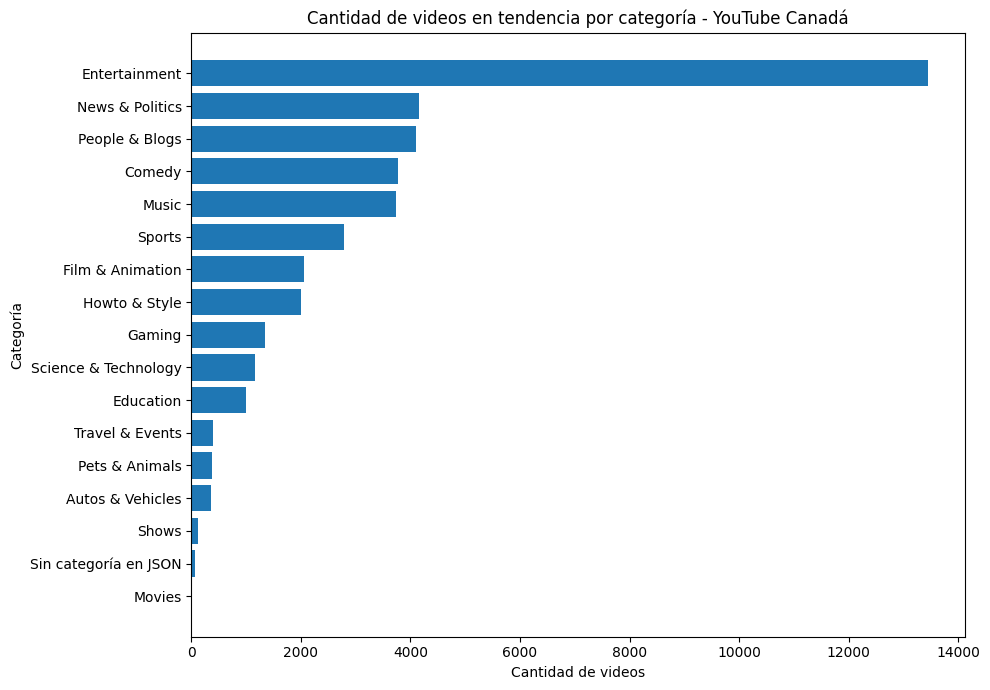

In [18]:
# Gráfico de cantidad de videos por categoría
conteo_cat = videos['category_title'].fillna('Sin categoría en JSON').value_counts().sort_values() 
plt.figure(figsize=(10, 7)) 
plt.barh(conteo_cat.index, conteo_cat.values) 
plt.title('Cantidad de videos en tendencia por categoría - YouTube Canadá') 
plt.xlabel('Cantidad de videos') 
plt.ylabel('Categoría') 
plt.tight_layout() 
plt.show()

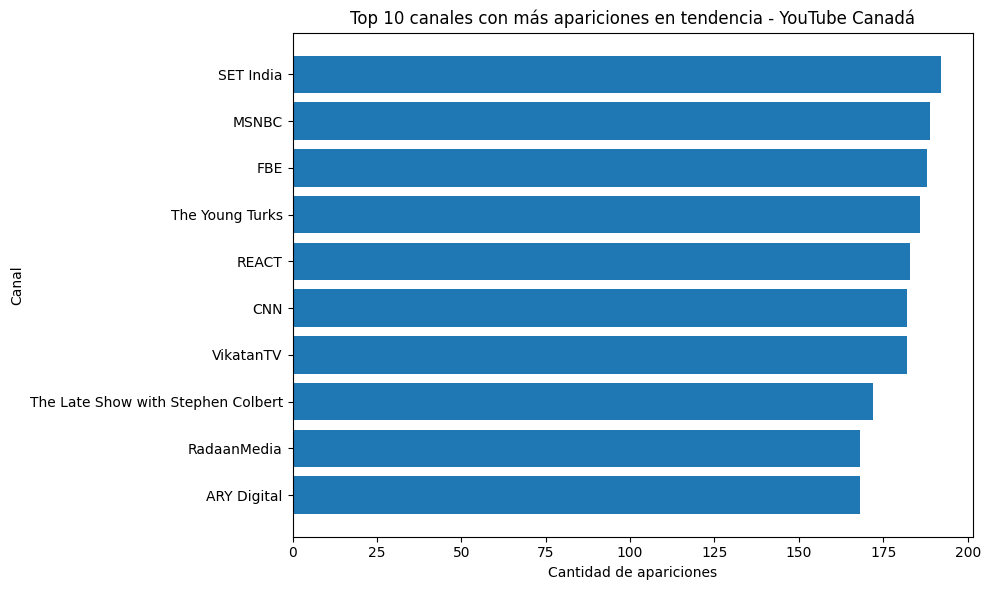

In [19]:
# Gráfico de top 10 canales con más apariciones 
top10_channels = videos['channel_title'].value_counts().head(10).sort_values() 
plt.figure(figsize=(10, 6)) 
plt.barh(top10_channels.index, top10_channels.values) 
plt.title('Top 10 canales con más apariciones en tendencia - YouTube Canadá') 
plt.xlabel('Cantidad de apariciones') 
plt.ylabel('Canal') 
plt.tight_layout() 
plt.show()

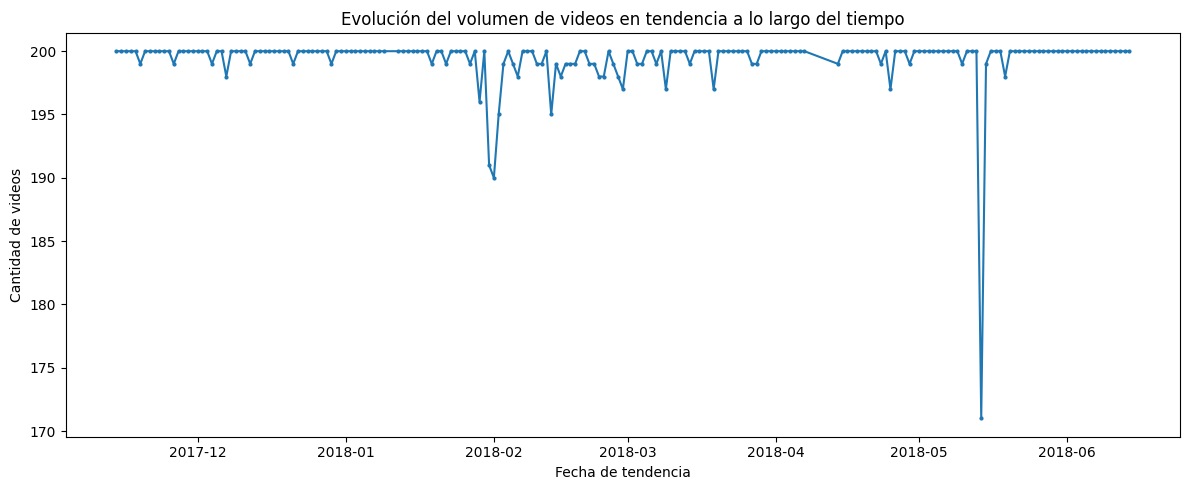

In [20]:
# Gráfico de evolución temporal del volumen de videos en tendencia 
videos_por_fecha = videos.groupby('trending_date_dt').size() 
plt.figure(figsize=(12, 5)) 
plt.plot(videos_por_fecha.index, videos_por_fecha.values, marker='o', markersize=2) 
plt.title('Evolución del volumen de videos en tendencia a lo largo del tiempo') 
plt.xlabel('Fecha de tendencia') 
plt.ylabel('Cantidad de videos') 
plt.tight_layout() 
plt.show()

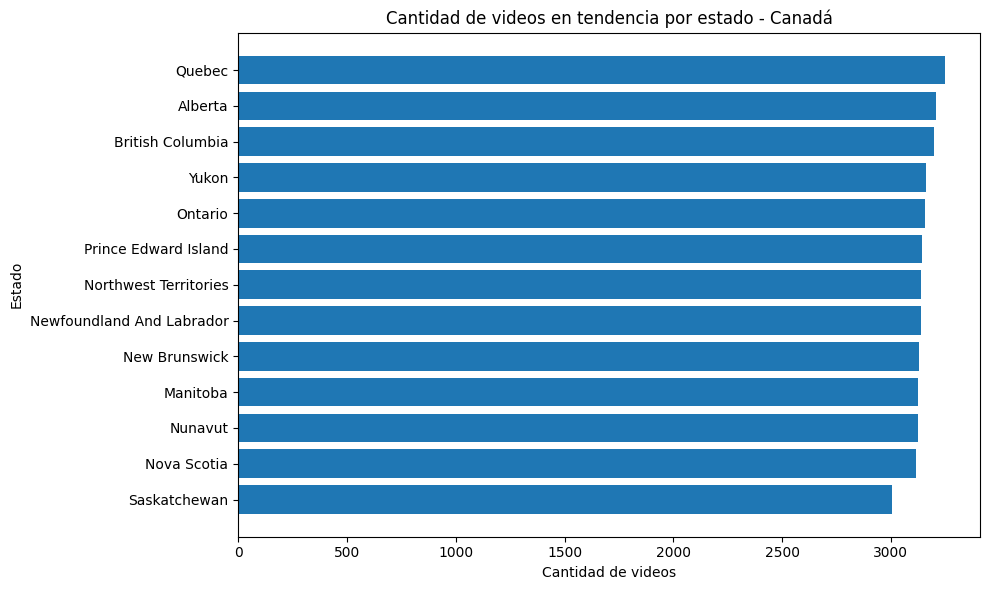

In [21]:
# Gráfico de cantidad de videos por estado 
conteo_estado = videos['state'].value_counts().sort_values() 
plt.figure(figsize=(10, 6)) 
plt.barh(conteo_estado.index, conteo_estado.values) 
plt.title('Cantidad de videos en tendencia por estado - Canadá') 
plt.xlabel('Cantidad de videos') 
plt.ylabel('Estado') 
plt.tight_layout() 
plt.show()

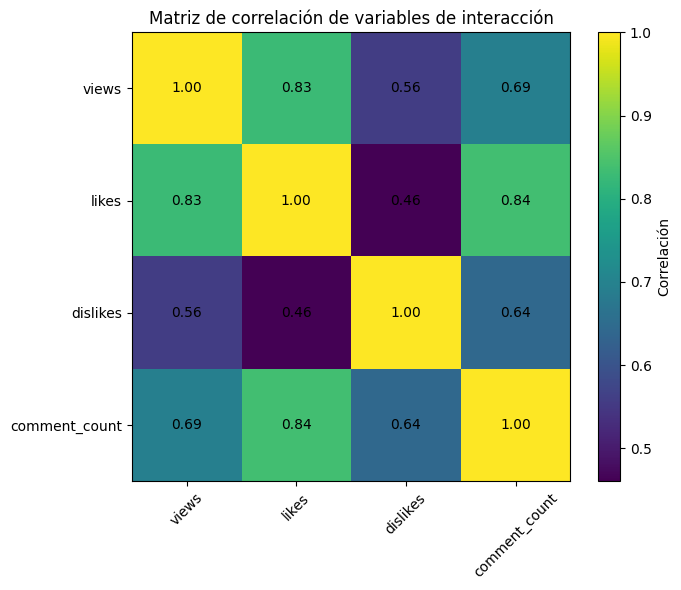

In [22]:
# Matriz de correlación visual 
corr = videos[['views', 'likes', 'dislikes', 'comment_count']].corr() 
plt.figure(figsize=(7, 6)) 
plt.imshow(corr, aspect='auto') 
plt.colorbar(label='Correlación') 
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45) 
plt.yticks(range(len(corr.index)), corr.index) 
plt.title('Matriz de correlación de variables de interacción') 
for i in range(len(corr.index)): 
    for j in range(len(corr.columns)): 
        plt.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center') 
plt.tight_layout() 
plt.show()

In [23]:
# Revisión de valores nulos 
calidad_nulos = pd.DataFrame({ 
    'columna': videos.columns, 
    'nulos': videos.isnull().sum().values, 
    'porcentaje_nulos': (videos.isnull().mean().values * 100).round(2) 
}).sort_values(by='nulos', ascending=False) 

calidad_nulos

,columna,nulos,porcentaje_nulos
15,description,1296,3.17
20,category_title,74,0.18
0,video_id,0,0.00
1,trending_date,0,0.00
4,category_id,0,0.00
5,publish_time,0,0.00
2,title,0,0.00
3,channel_title,0,0.00
7,views,0,0.00
6,tags,0,0.00


In [24]:
# Revisión de duplicados y videos repetidos 
print('Filas completamente duplicadas:', videos.duplicated().sum()) 
print('Videos únicos:', videos['video_id'].nunique()) 
print('Registros repetidos por video_id:', videos['video_id'].duplicated().sum()) 
videos_repetidos = videos['video_id'].value_counts().head(10).reset_index() 
videos_repetidos.columns = ['video_id', 'cantidad_apariciones'] 
videos_repetidos

Filas completamente duplicadas: 0
Videos únicos: 24427
Registros repetidos por video_id: 16454


,video_id,cantidad_apariciones
0,6ZfuNTqbHE8,8
1,UceaB4D0jpo,8
2,l_lblj8Cq0o,8
3,VYOjWnS4cMY,8
4,p8phGxzUC_Y,7
5,ZJDMWVZta3M,7
6,GOiDjiE8haM,7
7,MvFcY9rTPx8,7
8,vHwOMWGAg_o,7
9,VJwoSfTOhyM,7


In [25]:
# Revisión de valores cero en variables de interacción 
variables_interaccion = ['views', 'likes', 'dislikes', 'comment_count'] 
ceros = pd.DataFrame({ 
    'variable': variables_interaccion, 
    'cantidad_ceros': [(videos[col] == 0).sum() for col in variables_interaccion], 
    'porcentaje_ceros': [round((videos[col] == 0).mean() * 100, 2) for col in variables_interaccion] 
}) 

ceros

,variable,cantidad_ceros,porcentaje_ceros
0,views,0,0.00
1,likes,284,0.69
2,dislikes,393,0.96
3,comment_count,646,1.58


In [26]:
# Revisión de variables booleanas 
for col in ['comments_disabled', 'ratings_disabled', 'video_error_or_removed']: 
    print('\n', col) 
    print(videos[col].value_counts())


 comments_disabled
comments_disabled
False    40298
True       583
Name: count, dtype: int64

 ratings_disabled
ratings_disabled
False    40602
True       279
Name: count, dtype: int64

 video_error_or_removed
video_error_or_removed
False    40854
True        27
Name: count, dtype: int64


In [27]:
# Identificación de posibles outliers con método IQR 
outliers_resumen = [] 
for col in ['views', 'likes', 'dislikes', 'comment_count']: 
    q1 = videos[col].quantile(0.25) 
    q3 = videos[col].quantile(0.75) 
    iqr = q3 - q1 
    limite_inferior = q1 - 1.5 * iqr 
    limite_superior = q3 + 1.5 * iqr 
    cantidad_outliers = ((videos[col] < limite_inferior) | (videos[col] > limite_superior)).sum() 
    outliers_resumen.append([ col, q1, q3, iqr, limite_inferior, limite_superior, cantidad_outliers ]) 
outliers_resumen = pd.DataFrame(outliers_resumen, columns=[ 'variable', 'Q1', 'Q3', 'IQR', 'limite_inferior', 'limite_superior', 'cantidad_outliers' ]) 
outliers_resumen

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers
0,views,"143,902.00","963,302.00","819,400.00","-1,085,198.00","2,192,402.00",4464
1,likes,"2,191.00","28,717.00","26,526.00","-37,598.00","68,506.00",5045
2,dislikes,99.00,950.00,851.00,"-1,177.50","2,226.50",5337
3,comment_count,417.00,"3,713.00","3,296.00","-4,527.00","8,657.00",4877


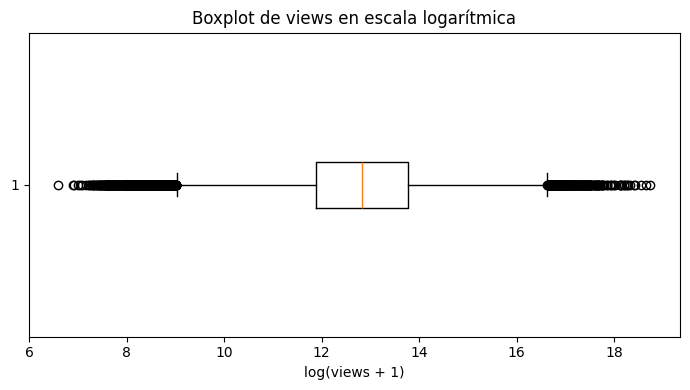

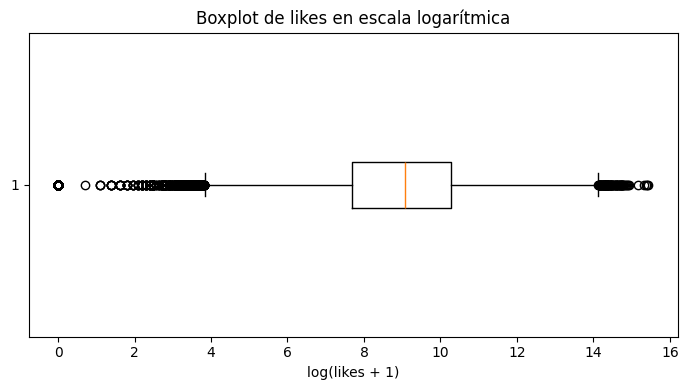

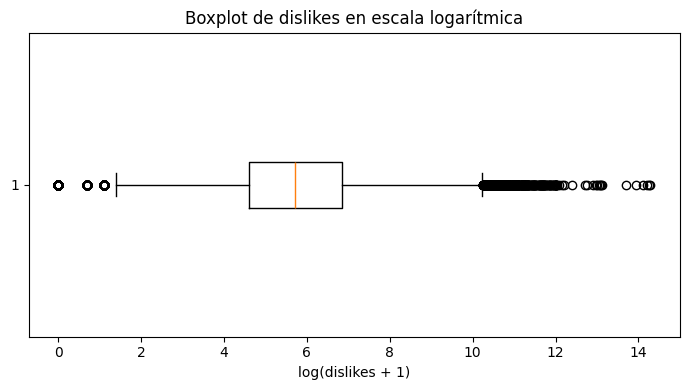

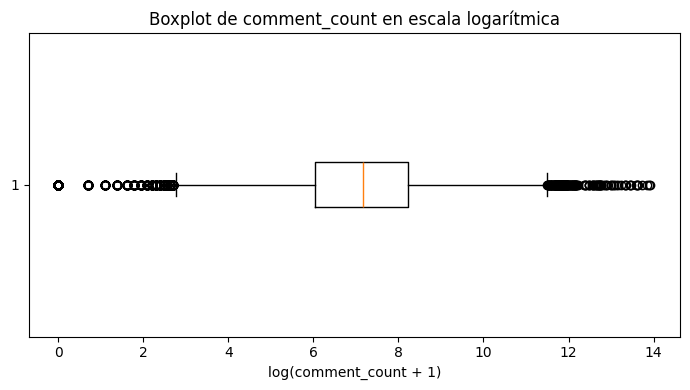

In [28]:
# Boxplots en escala logarítmica para variables de interacción 
for col in ['views', 'likes', 'dislikes', 'comment_count']: 
    plt.figure(figsize=(7, 4)) 
    plt.boxplot(np.log1p(videos[col]), vert=False) 
    plt.title(f'Boxplot de {col} en escala logarítmica') 
    plt.xlabel(f'log({col} + 1)') 
    plt.tight_layout() 
    plt.show()

In [29]:
# Punto de partida para la fase de preparación de datos 
# Se crea una copia del dataset trabajado en la fase de comprensión de datos 
videos_prep = videos.copy() 
print('Dataset copiado para preparación de datos.') 
print(f'Filas iniciales: {videos_prep.shape[0]:,}') 
print(f'Columnas iniciales: {videos_prep.shape[1]}')

Dataset copiado para preparación de datos.
Filas iniciales: 40,881
Columnas iniciales: 24


In [30]:
# Selección de variables relevantes para el análisis 
columnas_seleccionadas = [ 
    'video_id', 
    'trending_date', 
    'trending_date_dt', 
    'title', 
    'channel_title', 
    'category_id', 
    'category_title', 
    'publish_time', 
    'publish_time_dt', 
    'tags', 
    'views', 
    'likes', 
    'dislikes', 
    'comment_count', 
    'comments_disabled', 
    'ratings_disabled', 
    'video_error_or_removed', 
    'description', 
    'state', 
    'lat', 
    'lon', 
    'geometry', 
    'days_to_trend' 
] 

# Se conservan solo las columnas que existan en el dataset 
columnas_seleccionadas = [col for col in columnas_seleccionadas if col in videos_prep.columns] 
videos_prep = videos_prep[columnas_seleccionadas] 
print('Columnas seleccionadas:', len(columnas_seleccionadas)) 
videos_prep.head()

Columnas seleccionadas: 23


,video_id,trending_date,trending_date_dt,title,channel_title,category_id,category_title,publish_time,publish_time_dt,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,days_to_trend
0,n1WpP7iowLc,17.14.11,2017-11-14,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,Music,2017-11-10T17:00:03.000Z,2017-11-10 17:00:03+00:00,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/Interscope""|""Rap""",17158579,787425,43420,125882,False,False,False,Eminem's new track Walk on Water ft. Beyoncé is available everywhere: http:/...,Manitoba,50.15,-96.88,POINT (-96.88332178 50.15002545),3
1,0dBIkQ4Mz1M,17.14.11,2017-11-14,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,Comedy,2017-11-13T17:00:00.000Z,2017-11-13 17:00:00+00:00,"plush|""bad unboxing""|""unboxing""|""fan mail""|""idubbbztv""|""idubbbztv2""|""things""...",1014651,127794,1688,13030,False,False,False,STill got a lot of packages. Probably will last for another year. On a side ...,British Columbia,49.10,-116.52,POINT (-116.516697 49.09996035),0
2,5qpjK5DgCt4,17.14.11,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Lele Pons",Rudy Mancuso,23,Comedy,2017-11-12T19:05:24.000Z,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""|""racist""|""superman""|""love""|""r...",3191434,146035,5339,8181,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► https://www.youtube.com/channel/UC...,New Brunswick,45.27,-66.08,POINT (-66.07667505000001 45.26704185),1
3,d380meD0W0M,17.14.11,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,Entertainment,2017-11-12T18:01:41.000Z,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""idy""|""rhpc""|""dares""|""no truth""...",2095828,132239,1989,17518,False,False,False,"I know it's been a while since we did this show, but we're back with what mi...",Saskatchewan,50.93,-102.80,POINT (-102.7999891 50.93331097),1
4,2Vv-BfVoq4g,17.14.11,2017-11-14,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,Music,2017-11-09T11:04:14.000Z,2017-11-09 11:04:14+00:00,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cover""|""official""|""remix""|""officia...",33523622,1634130,21082,85067,False,False,False,🎧: https://ad.gt/yt-perfect\n💰: https://atlanti.cr/yt-album\nSubscribe to Ed...,Alberta,53.02,-112.82,POINT (-112.8166386 53.01669802),4


In [31]:
# Tabla resumen de las variables seleccionadas 
variables_seleccionadas = pd.DataFrame({ 
    'Variable seleccionada': videos_prep.columns, 
    'Tipo de dato': videos_prep.dtypes.astype(str).values, 
    'Uso principal': [ 
        'Identificación del video' if col == 'video_id' else 
        'Análisis temporal' if col in ['trending_date', 'trending_date_dt', 'publish_time', 'publish_time_dt', 'days_to_trend'] else 
        'Análisis descriptivo del contenido' if col in ['title', 'tags', 'description'] else 
        'Análisis por canal' if col == 'channel_title' else 
        'Análisis por categoría' if col in ['category_id', 'category_title'] else 
        'Métrica de interacción' if col in ['views', 'likes', 'dislikes', 'comment_count'] else 
        'Control de calidad/interacción' if col in ['comments_disabled', 'ratings_disabled', 'video_error_or_removed'] else 
        'Análisis geográfico' if col in ['state', 'lat', 'lon', 'geometry'] else 
        'Otro' 
        for col in videos_prep.columns 
    ] 
}) 

variables_seleccionadas

,Variable seleccionada,Tipo de dato,Uso principal
0,video_id,object,Identificación del video
1,trending_date,object,Análisis temporal
2,trending_date_dt,datetime64[ns],Análisis temporal
3,title,object,Análisis descriptivo del contenido
4,channel_title,object,Análisis por canal
5,category_id,int64,Análisis por categoría
6,category_title,object,Análisis por categoría
7,publish_time,object,Análisis temporal
8,publish_time_dt,"datetime64[ns, UTC]",Análisis temporal
9,tags,object,Análisis descriptivo del contenido


In [32]:
# Revisión y eliminación de filas completamente duplicadas 
filas_antes = videos_prep.shape[0] 
duplicados_completos = videos_prep.duplicated().sum() 
videos_prep = videos_prep.drop_duplicates() 
filas_despues = videos_prep.shape[0] 
print('Filas antes de eliminar duplicados completos:', filas_antes) 
print('Filas completamente duplicadas encontradas:', duplicados_completos) 
print('Filas después de eliminar duplicados completos:', filas_despues)

Filas antes de eliminar duplicados completos: 40881
Filas completamente duplicadas encontradas: 0
Filas después de eliminar duplicados completos: 40881


In [33]:
# Limpieza de la variable days_to_trend 
print('Valores negativos antes del ajuste:', (videos_prep['days_to_trend'] < 0).sum()) 
videos_prep.loc[videos_prep['days_to_trend'] < 0, 'days_to_trend'] = 0 
print('Valores negativos después del ajuste:', (videos_prep['days_to_trend'] < 0).sum()) 
videos_prep[['publish_time_dt', 'trending_date_dt', 'days_to_trend']].head(10)

Valores negativos antes del ajuste: 2031
Valores negativos después del ajuste: 0


,publish_time_dt,trending_date_dt,days_to_trend
0,2017-11-10 17:00:03+00:00,2017-11-14,3
1,2017-11-13 17:00:00+00:00,2017-11-14,0
2,2017-11-12 19:05:24+00:00,2017-11-14,1
3,2017-11-12 18:01:41+00:00,2017-11-14,1
4,2017-11-09 11:04:14+00:00,2017-11-14,4
5,2017-11-13 07:37:51+00:00,2017-11-14,0
6,2017-11-12 23:52:13+00:00,2017-11-14,1
7,2017-11-13 17:13:01+00:00,2017-11-14,0
8,2017-11-12 20:19:24+00:00,2017-11-14,1
9,2017-11-10 14:10:46+00:00,2017-11-14,3


In [34]:
# Revisión de columnas booleanas 
columnas_booleanas = ['comments_disabled', 'ratings_disabled', 'video_error_or_removed'] 
for col in columnas_booleanas: 
    print(f'\nVariable: {col}') 
    print(videos_prep[col].value_counts())


Variable: comments_disabled
comments_disabled
False    40298
True       583
Name: count, dtype: int64

Variable: ratings_disabled
ratings_disabled
False    40602
True       279
Name: count, dtype: int64

Variable: video_error_or_removed
video_error_or_removed
False    40854
True        27
Name: count, dtype: int64


In [35]:
# Revisión de valores faltantes antes del tratamiento 
nulos_antes = pd.DataFrame({ 
    'columna': videos_prep.columns, 
    'nulos_antes': videos_prep.isnull().sum().values, 
    'porcentaje_nulos_antes': (videos_prep.isnull().mean().values * 100).round(2) 
}).sort_values(by='nulos_antes', ascending=False) 

nulos_antes

,columna,nulos_antes,porcentaje_nulos_antes
17,description,1296,3.17
6,category_title,74,0.18
1,trending_date,0,0.00
2,trending_date_dt,0,0.00
3,title,0,0.00
4,channel_title,0,0.00
0,video_id,0,0.00
5,category_id,0,0.00
7,publish_time,0,0.00
9,tags,0,0.00


In [36]:
videos_prep['description'] = videos_prep['description'].fillna('Sin descripción') 
videos_prep['category_title'] = videos_prep['category_title'].fillna('Sin categoría en JSON') 
nulos_despues = pd.DataFrame({ 
    'columna': videos_prep.columns, 
    'nulos_despues': videos_prep.isnull().sum().values, 
    'porcentaje_nulos_despues': (videos_prep.isnull().mean().values * 100).round(2) 
}).sort_values(by='nulos_despues', ascending=False) 
nulos_despues

,columna,nulos_despues,porcentaje_nulos_despues
0,video_id,0,0.00
1,trending_date,0,0.00
2,trending_date_dt,0,0.00
3,title,0,0.00
4,channel_title,0,0.00
5,category_id,0,0.00
6,category_title,0,0.00
7,publish_time,0,0.00
8,publish_time_dt,0,0.00
9,tags,0,0.00


In [37]:
# Comparación resumida de valores faltantes antes y después 
comparacion_nulos = nulos_antes[['columna', 'nulos_antes']].merge( nulos_despues[['columna', 'nulos_despues']], on='columna', how='left' ) 
comparacion_nulos.sort_values(by='nulos_antes', ascending=False).head(10)

,columna,nulos_antes,nulos_despues
0,description,1296,0
1,category_title,74,0
2,trending_date,0,0
3,trending_date_dt,0,0
4,title,0,0
5,channel_title,0,0
6,video_id,0,0
7,category_id,0,0
8,publish_time,0,0
9,tags,0,0


In [38]:
# Identificación de outliers con el método IQR 
variables_outliers = ['views', 'likes', 'dislikes', 'comment_count'] 
outliers_resumen = [] 
for col in variables_outliers: 
    q1 = videos_prep[col].quantile(0.25) 
    q3 = videos_prep[col].quantile(0.75) 
    iqr = q3 - q1 
    limite_inferior = q1 - 1.5 * iqr 
    limite_superior = q3 + 1.5 * iqr 
    cantidad_outliers = ((videos_prep[col] < limite_inferior) | (videos_prep[col] > limite_superior)).sum() 
    outliers_resumen.append([ col, q1, q3, iqr, limite_inferior, limite_superior, cantidad_outliers ]) 

outliers_resumen = pd.DataFrame(outliers_resumen, columns=[ 
    'variable', 'Q1', 'Q3', 'IQR', 'limite_inferior', 'limite_superior', 'cantidad_outliers' ])
 
outliers_resumen

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers
0,views,"143,902.00","963,302.00","819,400.00","-1,085,198.00","2,192,402.00",4464
1,likes,"2,191.00","28,717.00","26,526.00","-37,598.00","68,506.00",5045
2,dislikes,99.00,950.00,851.00,"-1,177.50","2,226.50",5337
3,comment_count,417.00,"3,713.00","3,296.00","-4,527.00","8,657.00",4877


In [39]:
# Tratamiento de outliers mediante transformación logarítmica 
videos_prep['log_views'] = np.log1p(videos_prep['views']) 
videos_prep['log_likes'] = np.log1p(videos_prep['likes']) 
videos_prep['log_dislikes'] = np.log1p(videos_prep['dislikes']) 
videos_prep['log_comment_count'] = np.log1p(videos_prep['comment_count']) 
videos_prep[['views', 'log_views', 'likes', 'log_likes', 'comment_count', 'log_comment_count']].head(10)

,views,log_views,likes,log_likes,comment_count,log_comment_count
0,17158579,16.66,787425,13.58,125882,11.74
1,1014651,13.83,127794,11.76,13030,9.48
2,3191434,14.98,146035,11.89,8181,9.01
3,2095828,14.56,132239,11.79,17518,9.77
4,33523622,17.33,1634130,14.31,85067,11.35
5,1309699,14.09,103755,11.55,12143,9.40
6,2987945,14.91,187464,12.14,26629,10.19
7,748374,13.53,57534,10.96,15959,9.68
8,4477587,15.31,292837,12.59,36391,10.50
9,505161,13.13,4135,8.33,1484,7.30


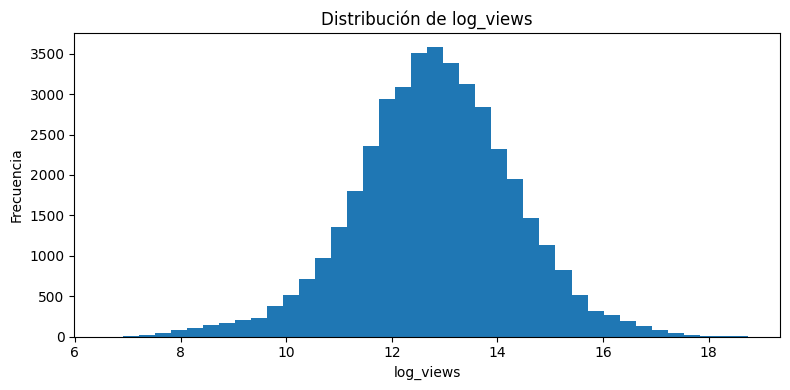

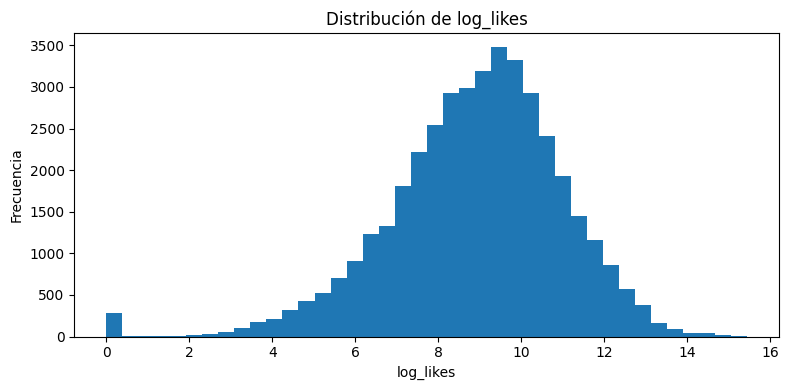

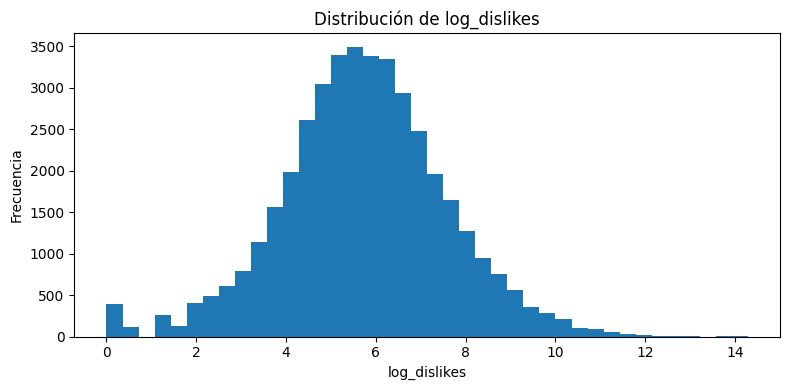

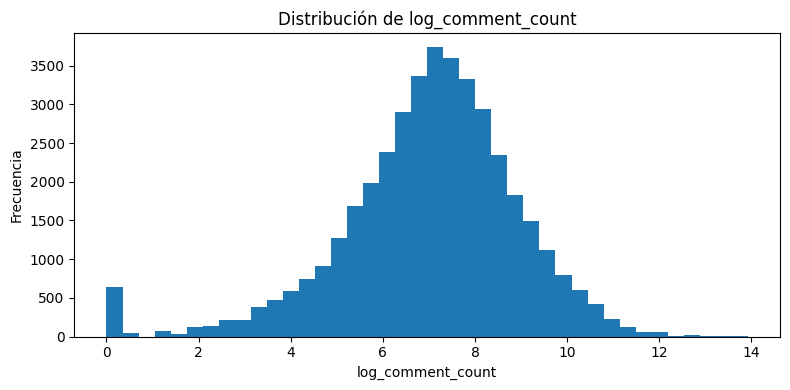

In [40]:
# Visualización de variables transformadas 
for col in ['log_views', 'log_likes', 'log_dislikes', 'log_comment_count']: 
    plt.figure(figsize=(8, 4)) 
    plt.hist(videos_prep[col], bins=40) 
    plt.title(f'Distribución de {col}') 
    plt.xlabel(col) 
    plt.ylabel('Frecuencia') 
    plt.tight_layout() 
    plt.show()

In [41]:
# Revisión de categorías disponibles en el JSON 
categories.head(10)

,category_id,category_title,assignable
0,1,Film & Animation,True
1,2,Autos & Vehicles,True
2,10,Music,True
3,15,Pets & Animals,True
4,17,Sports,True
5,18,Short Movies,False
6,19,Travel & Events,True
7,20,Gaming,True
8,21,Videoblogging,False
9,22,People & Blogs,True


In [42]:
# Verificación de la integración entre CSV y JSON 
videos_prep[['category_id', 'category_title']].drop_duplicates().sort_values('category_id').head(20)

,category_id,category_title
12,1,Film & Animation
86,2,Autos & Vehicles
0,10,Music
53,15,Pets & Animals
41,17,Sports
66,19,Travel & Events
33,20,Gaming
7,22,People & Blogs
1,23,Comedy
3,24,Entertainment


In [43]:
# Verificación de categorías sin coincidencia
categorias_sin_json = videos_prep[videos_prep['category_title'] == 'Sin categoría en JSON']['category_id'].unique() 
print('Categorías sin coincidencia en JSON:', categorias_sin_json) 
print('Cantidad de registros sin categoría en JSON:', (videos_prep['category_title'] == 'Sin categoría en JSON').sum())

Categorías sin coincidencia en JSON: [29]
Cantidad de registros sin categoría en JSON: 74


In [44]:
# Construcción de variables derivadas de interacción 
videos_prep['like_dislike_ratio'] = (videos_prep['likes'] + 1) / (videos_prep['dislikes'] + 1) 
videos_prep['views_comments_ratio'] = videos_prep['views'] / (videos_prep['comment_count'] + 1) 
videos_prep['like_rate'] = videos_prep['likes'] / (videos_prep['views'] + 1) 
videos_prep['dislike_rate'] = videos_prep['dislikes'] / (videos_prep['views'] + 1) 
videos_prep['comment_rate'] = videos_prep['comment_count'] / (videos_prep['views'] + 1) 
videos_prep[['views', 'likes', 'dislikes', 'comment_count', 'like_dislike_ratio', 'views_comments_ratio', 'like_rate', 'dislike_rate', 'comment_rate']].head(10)

,views,likes,dislikes,comment_count,like_dislike_ratio,views_comments_ratio,like_rate,dislike_rate,comment_rate
0,17158579,787425,43420,125882,18.13,136.31,0.05,0.00,0.01
1,1014651,127794,1688,13030,75.66,77.86,0.13,0.00,0.01
2,3191434,146035,5339,8181,27.35,390.06,0.05,0.00,0.00
3,2095828,132239,1989,17518,66.45,119.63,0.06,0.00,0.01
4,33523622,1634130,21082,85067,77.51,394.08,0.05,0.00,0.00
5,1309699,103755,4613,12143,22.49,107.85,0.08,0.00,0.01
6,2987945,187464,9850,26629,19.03,112.20,0.06,0.00,0.01
7,748374,57534,2967,15959,19.39,46.89,0.08,0.00,0.02
8,4477587,292837,4123,36391,71.01,123.04,0.07,0.00,0.01
9,505161,4135,976,1484,4.23,340.18,0.01,0.00,0.00


In [45]:
# Construcción de variables temporales 
videos_prep['trending_year'] = videos_prep['trending_date_dt'].dt.year 
videos_prep['trending_month'] = videos_prep['trending_date_dt'].dt.month 
videos_prep['trending_weekday'] = videos_prep['trending_date_dt'].dt.day_name() 
videos_prep['is_weekend'] = videos_prep['trending_date_dt'].dt.dayofweek >= 5 
videos_prep[['trending_date_dt', 'trending_year', 'trending_month', 'trending_weekday', 'is_weekend', 'days_to_trend']].head(10)

,trending_date_dt,trending_year,trending_month,trending_weekday,is_weekend,days_to_trend
0,2017-11-14,2017,11,Tuesday,False,3
1,2017-11-14,2017,11,Tuesday,False,0
2,2017-11-14,2017,11,Tuesday,False,1
3,2017-11-14,2017,11,Tuesday,False,1
4,2017-11-14,2017,11,Tuesday,False,4
5,2017-11-14,2017,11,Tuesday,False,0
6,2017-11-14,2017,11,Tuesday,False,1
7,2017-11-14,2017,11,Tuesday,False,0
8,2017-11-14,2017,11,Tuesday,False,1
9,2017-11-14,2017,11,Tuesday,False,3


In [46]:
# Construcción de variables descriptivas del contenido 
videos_prep['title_length'] = videos_prep['title'].astype(str).str.len() 
videos_prep['description_length'] = videos_prep['description'].astype(str).str.len() 
videos_prep['tag_count'] = videos_prep['tags'].astype(str).apply( lambda x: 0 if x == '[none]' else len(x.split('|')) ) 
videos_prep[['title', 'title_length', 'tags', 'tag_count', 'description_length']].head(10)

,title,title_length,tags,tag_count,description_length
0,Eminem - Walk On Water (Audio) ft. Beyoncé,42,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/Interscope""|""Rap""",6,594
1,PLUSH - Bad Unboxing Fan Mail,29,"plush|""bad unboxing""|""unboxing""|""fan mail""|""idubbbztv""|""idubbbztv2""|""things""...",11,704
2,"Racist Superman | Rudy Mancuso, King Bach & Lele Pons",53,"racist superman|""rudy""|""mancuso""|""king""|""bach""|""racist""|""superman""|""love""|""r...",23,1177
3,I Dare You: GOING BALD!?,24,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""idy""|""rhpc""|""dares""|""no truth""...",14,636
4,Ed Sheeran - Perfect (Official Music Video),43,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cover""|""official""|""remix""|""officia...",10,1250
5,Jake Paul Says Alissa Violet CHEATED with LOGAN PAUL! #DramaAlert Team 10 vs...,93,"#DramaAlert|""Drama""|""Alert""|""DramaAlert""|""keemstar""|""youtube news""|""jake pau...",17,901
6,Vanoss Superhero School - New Students,38,"Funny Moments|""Montage video games""|""gaming""|""Vanoss""|""VanossGaming""|""Gamepl...",25,2532
7,WE WANT TO TALK ABOUT OUR MARRIAGE,34,SHANtell martin,1,1410
8,THE LOGANG MADE HISTORY. LOL. AGAIN.,36,"logan paul vlog|""logan paul""|""logan""|""paul""|""olympics""|""logan paul youtube""|...",28,748
9,Finally Sheldon is winning an argument about the existence of God,65,"God|""Sheldon Cooper""|""Young Sheldon""",3,75


In [47]:
# Creación del dataset final preparado 
videos_clean = videos_prep.copy() 
print('Dataset final preparado.') 
print(f'Filas finales: {videos_clean.shape[0]:,}') 
print(f'Columnas finales: {videos_clean.shape[1]}')

Dataset final preparado.
Filas finales: 40,881
Columnas finales: 39


In [48]:
# Vista previa del dataset final preparado 
videos_clean.head()

,video_id,trending_date,trending_date_dt,title,channel_title,category_id,category_title,publish_time,publish_time_dt,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,description,state,lat,lon,geometry,days_to_trend,log_views,log_likes,log_dislikes,log_comment_count,like_dislike_ratio,views_comments_ratio,like_rate,dislike_rate,comment_rate,trending_year,trending_month,trending_weekday,is_weekend,title_length,description_length,tag_count
0,n1WpP7iowLc,17.14.11,2017-11-14,Eminem - Walk On Water (Audio) ft. Beyoncé,EminemVEVO,10,Music,2017-11-10T17:00:03.000Z,2017-11-10 17:00:03+00:00,"Eminem|""Walk""|""On""|""Water""|""Aftermath/Shady/Interscope""|""Rap""",17158579,787425,43420,125882,False,False,False,Eminem's new track Walk on Water ft. Beyoncé is available everywhere: http:/...,Manitoba,50.15,-96.88,POINT (-96.88332178 50.15002545),3,16.66,13.58,10.68,11.74,18.13,136.31,0.05,0.00,0.01,2017,11,Tuesday,False,42,594,6
1,0dBIkQ4Mz1M,17.14.11,2017-11-14,PLUSH - Bad Unboxing Fan Mail,iDubbbzTV,23,Comedy,2017-11-13T17:00:00.000Z,2017-11-13 17:00:00+00:00,"plush|""bad unboxing""|""unboxing""|""fan mail""|""idubbbztv""|""idubbbztv2""|""things""...",1014651,127794,1688,13030,False,False,False,STill got a lot of packages. Probably will last for another year. On a side ...,British Columbia,49.10,-116.52,POINT (-116.516697 49.09996035),0,13.83,11.76,7.43,9.48,75.66,77.86,0.13,0.00,0.01,2017,11,Tuesday,False,29,704,11
2,5qpjK5DgCt4,17.14.11,2017-11-14,"Racist Superman | Rudy Mancuso, King Bach & Lele Pons",Rudy Mancuso,23,Comedy,2017-11-12T19:05:24.000Z,2017-11-12 19:05:24+00:00,"racist superman|""rudy""|""mancuso""|""king""|""bach""|""racist""|""superman""|""love""|""r...",3191434,146035,5339,8181,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► https://www.youtube.com/channel/UC...,New Brunswick,45.27,-66.08,POINT (-66.07667505000001 45.26704185),1,14.98,11.89,8.58,9.01,27.35,390.06,0.05,0.00,0.00,2017,11,Tuesday,False,53,1177,23
3,d380meD0W0M,17.14.11,2017-11-14,I Dare You: GOING BALD!?,nigahiga,24,Entertainment,2017-11-12T18:01:41.000Z,2017-11-12 18:01:41+00:00,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""idy""|""rhpc""|""dares""|""no truth""...",2095828,132239,1989,17518,False,False,False,"I know it's been a while since we did this show, but we're back with what mi...",Saskatchewan,50.93,-102.80,POINT (-102.7999891 50.93331097),1,14.56,11.79,7.60,9.77,66.45,119.63,0.06,0.00,0.01,2017,11,Tuesday,False,24,636,14
4,2Vv-BfVoq4g,17.14.11,2017-11-14,Ed Sheeran - Perfect (Official Music Video),Ed Sheeran,10,Music,2017-11-09T11:04:14.000Z,2017-11-09 11:04:14+00:00,"edsheeran|""ed sheeran""|""acoustic""|""live""|""cover""|""official""|""remix""|""officia...",33523622,1634130,21082,85067,False,False,False,🎧: https://ad.gt/yt-perfect\n💰: https://atlanti.cr/yt-album\nSubscribe to Ed...,Alberta,53.02,-112.82,POINT (-112.8166386 53.01669802),4,17.33,14.31,9.96,11.35,77.51,394.08,0.05,0.00,0.00,2017,11,Tuesday,False,43,1250,10


In [ ]:
# Exportación del dataset final preparado 
output_path = DATA_DIR / 'CAvideos_clean.csv' 
videos_clean.to_csv(output_path, index=False, encoding='utf-8') 
print('Dataset final exportado correctamente.') 
print('Ruta del archivo:', output_path) 
print('¿Existe el archivo exportado?', output_path.exists())

Dataset final exportado correctamente.
Ruta del archivo: c:\Users\ianla\Documentos\UPC\2026-1 - 5to Ciclo\Fundamentos Data Science\TF\CAvideos_clean.csv
¿Existe el archivo exportado? True


In [50]:
# Requerimiento 1: Categorías con mayor tendencia 
req1_categorias_tendencia = videos_clean['category_title'].value_counts().reset_index() 
req1_categorias_tendencia.columns = ['category_title', 'cantidad_videos'] 
req1_categorias_tendencia

,category_title,cantidad_videos
0,Entertainment,13451
1,News & Politics,4159
2,People & Blogs,4105
3,Comedy,3773
4,Music,3731
5,Sports,2787
6,Film & Animation,2060
7,Howto & Style,2007
8,Gaming,1344
9,Science & Technology,1155


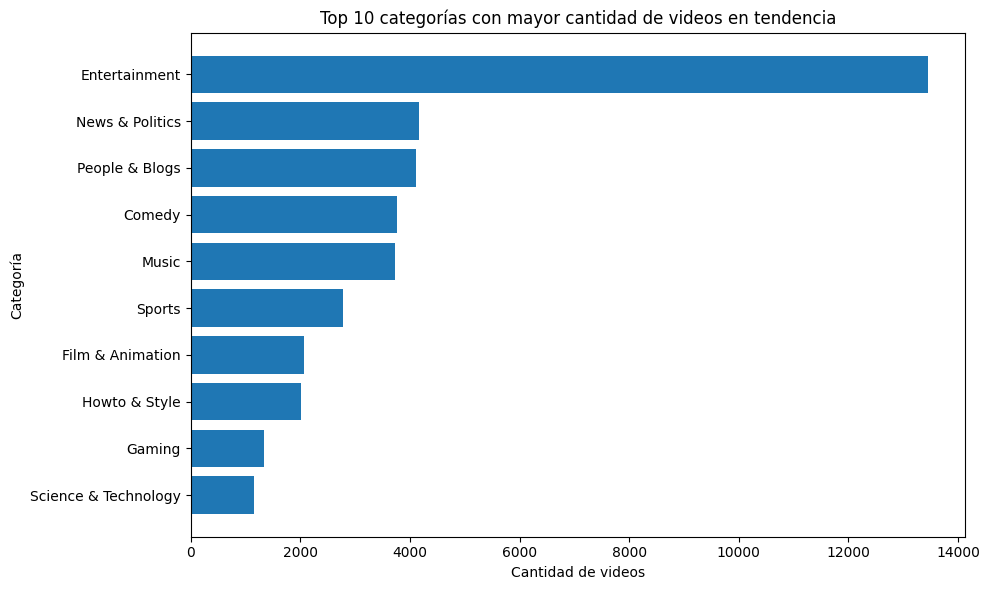

In [51]:
# Visualización del requerimiento 1 
top_req1 = req1_categorias_tendencia.head(10).sort_values('cantidad_videos') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_req1['category_title'], top_req1['cantidad_videos']) 
plt.title('Top 10 categorías con mayor cantidad de videos en tendencia') 
plt.xlabel('Cantidad de videos') 
plt.ylabel('Categoría') 
plt.tight_layout() 
plt.show()

In [52]:
# Requerimiento 2: Categorías con más likes y dislikes 
req2_interaccion_categoria = videos_clean.groupby('category_title').agg( 
    cantidad_videos=('video_id', 'count'), 
    total_likes=('likes', 'sum'), 
    promedio_likes=('likes', 'mean'), 
    total_dislikes=('dislikes', 'sum'), 
    promedio_dislikes=('dislikes', 'mean') 
).reset_index() 
req2_interaccion_categoria.sort_values('promedio_likes', ascending=False)

,category_title,cantidad_videos,total_likes,promedio_likes,total_dislikes,promedio_dislikes
8,Music,3731,564447530,"151,285.86",22098190,"5,922.86"
14,Sin categoría en JSON,74,10242613,"138,413.69",2325807,"31,429.82"
1,Comedy,3773,196046674,"51,960.42",5372515,"1,423.94"
7,Movies,6,252905,"42,150.83",12280,"2,046.67"
5,Gaming,1344,51726552,"38,487.02",2446882,"1,820.60"
4,Film & Animation,2060,77802003,"37,767.96",3111259,"1,510.32"
12,Science & Technology,1155,42814598,"37,068.92",1791153,"1,550.78"
3,Entertainment,13451,387245433,"28,789.34",25791583,"1,917.45"
10,People & Blogs,4105,105388564,"25,673.22",9480796,"2,309.57"
6,Howto & Style,2007,51183104,"25,502.29",1730520,862.24


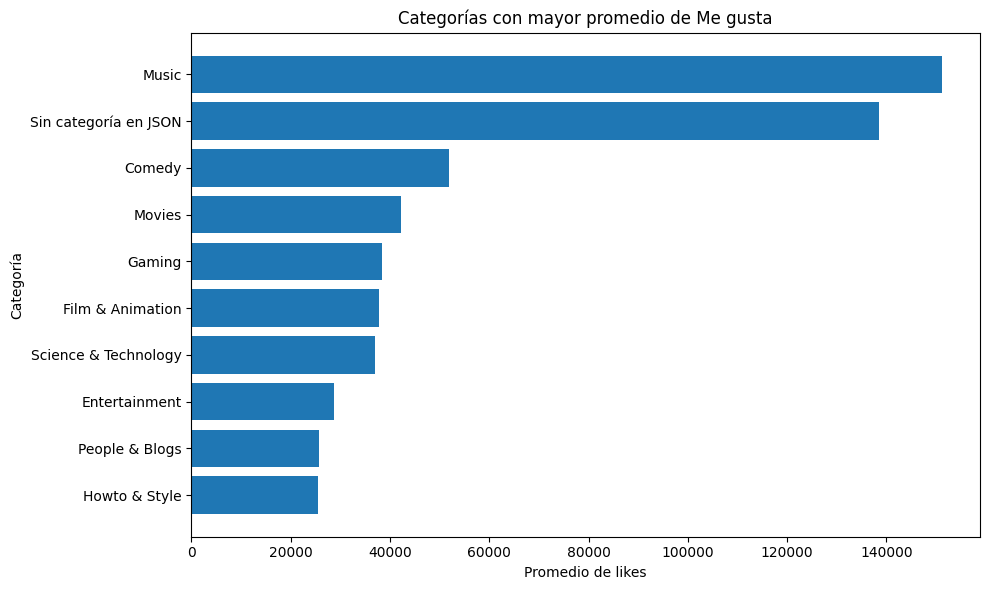

In [53]:
# Visualización de categorías que más gustan según promedio de likes 
top_likes = req2_interaccion_categoria.sort_values('promedio_likes', ascending=False).head(10).sort_values('promedio_likes') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_likes['category_title'], top_likes['promedio_likes']) 
plt.title('Categorías con mayor promedio de Me gusta') 
plt.xlabel('Promedio de likes') 
plt.ylabel('Categoría') 
plt.tight_layout() 
plt.show()

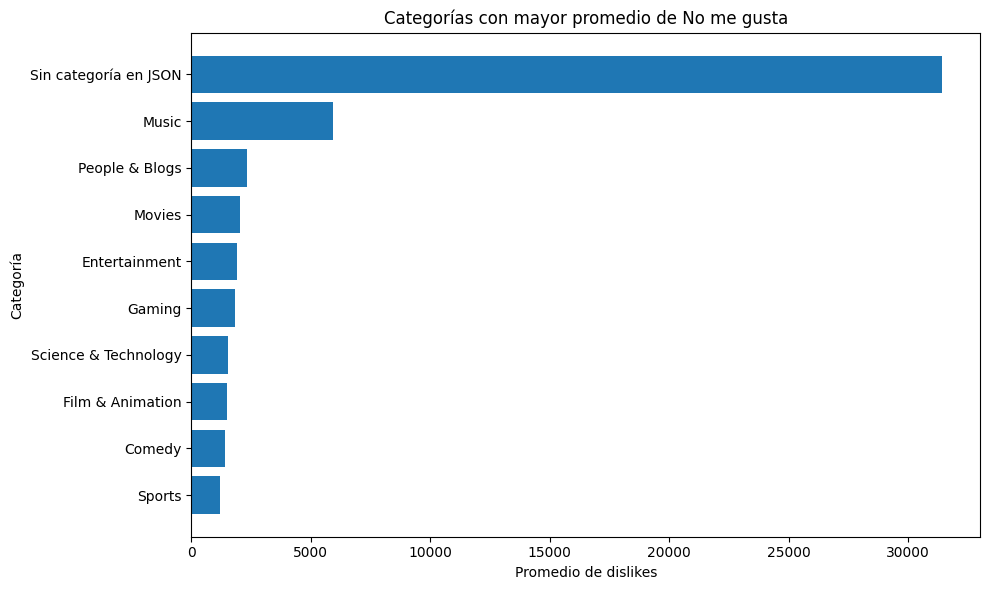

In [54]:
# Visualización de categorías con mayor promedio de dislikes 
top_dislikes = req2_interaccion_categoria.sort_values('promedio_dislikes', ascending=False).head(10).sort_values('promedio_dislikes') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_dislikes['category_title'], top_dislikes['promedio_dislikes']) 
plt.title('Categorías con mayor promedio de No me gusta') 
plt.xlabel('Promedio de dislikes') 
plt.ylabel('Categoría') 
plt.tight_layout() 
plt.show()

In [55]:
# Requerimiento 3: Ratio likes/dislikes por categoría 
req3_ratio_categoria = videos_clean.groupby('category_title').agg( 
    cantidad_videos=('video_id', 'count'), 
    total_likes=('likes', 'sum'), 
    total_dislikes=('dislikes', 'sum') 
).reset_index() 

req3_ratio_categoria['like_dislike_ratio'] = ( (req3_ratio_categoria['total_likes'] + 1) / (req3_ratio_categoria['total_dislikes'] + 1) ) 
req3_ratio_categoria.sort_values('like_dislike_ratio', ascending=False)

,category_title,cantidad_videos,total_likes,total_dislikes,like_dislike_ratio
11,Pets & Animals,369,8830736,185003,47.73
1,Comedy,3773,196046674,5372515,36.49
6,Howto & Style,2007,51183104,1730520,29.58
16,Travel & Events,392,3750914,129861,28.88
2,Education,991,20972402,793448,26.43
8,Music,3731,564447530,22098190,25.54
4,Film & Animation,2060,77802003,3111259,25.01
0,Autos & Vehicles,353,4732114,197776,23.93
12,Science & Technology,1155,42814598,1791153,23.90
5,Gaming,1344,51726552,2446882,21.14


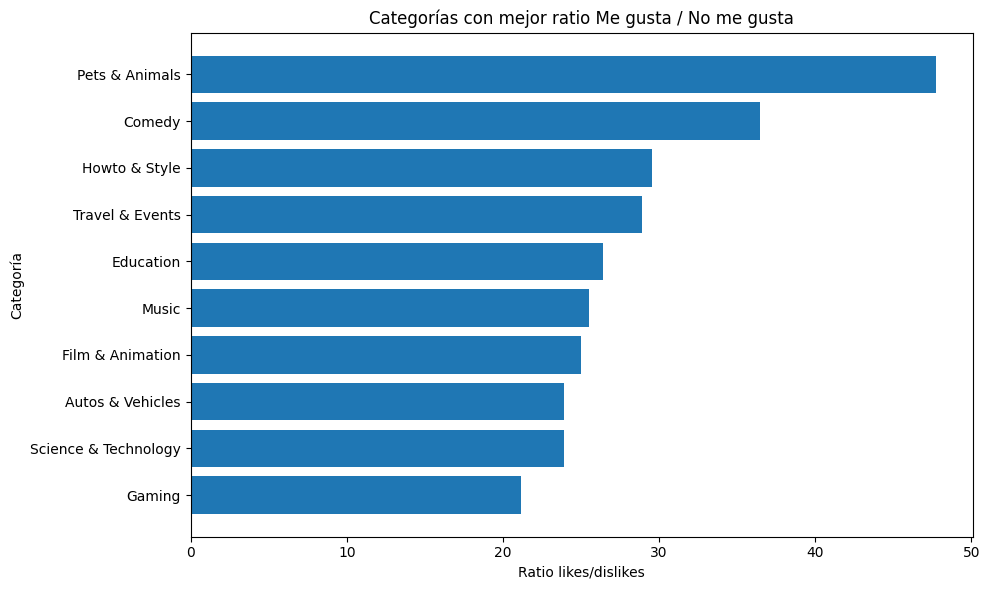

In [56]:
# Visualización del requerimiento 3 
top_req3 = req3_ratio_categoria.sort_values('like_dislike_ratio', ascending=False).head(10).sort_values('like_dislike_ratio') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_req3['category_title'], top_req3['like_dislike_ratio']) 
plt.title('Categorías con mejor ratio Me gusta / No me gusta') 
plt.xlabel('Ratio likes/dislikes') 
plt.ylabel('Categoría') 
plt.tight_layout() 
plt.show()

In [57]:
# Requerimiento 4: Ratio vistas/comentarios por categoría 
req4_ratio_categoria = videos_clean.groupby('category_title').agg( 
    cantidad_videos=('video_id', 'count'), 
    total_views=('views', 'sum'), 
    total_comments=('comment_count', 'sum') 
).reset_index() 
req4_ratio_categoria['views_comments_ratio'] = ( req4_ratio_categoria['total_views'] / (req4_ratio_categoria['total_comments'] + 1) ) 
req4_ratio_categoria.sort_values('views_comments_ratio', ascending=False)

,category_title,cantidad_videos,total_views,total_comments,views_comments_ratio
7,Movies,6,17120490,13979,"1,224.64"
13,Shows,124,71549508,77243,926.28
15,Sports,2787,2997652188,7661342,391.27
4,Film & Animation,2060,2939060844,10086573,291.38
8,Music,3731,13179850194,52435252,251.35
3,Entertainment,13451,13671215509,55313036,247.16
16,Travel & Events,392,143746952,609953,235.67
12,Science & Technology,1155,1425090421,7209219,197.68
0,Autos & Vehicles,353,200066074,1016188,196.88
10,People & Blogs,4105,3228227926,16818201,191.95


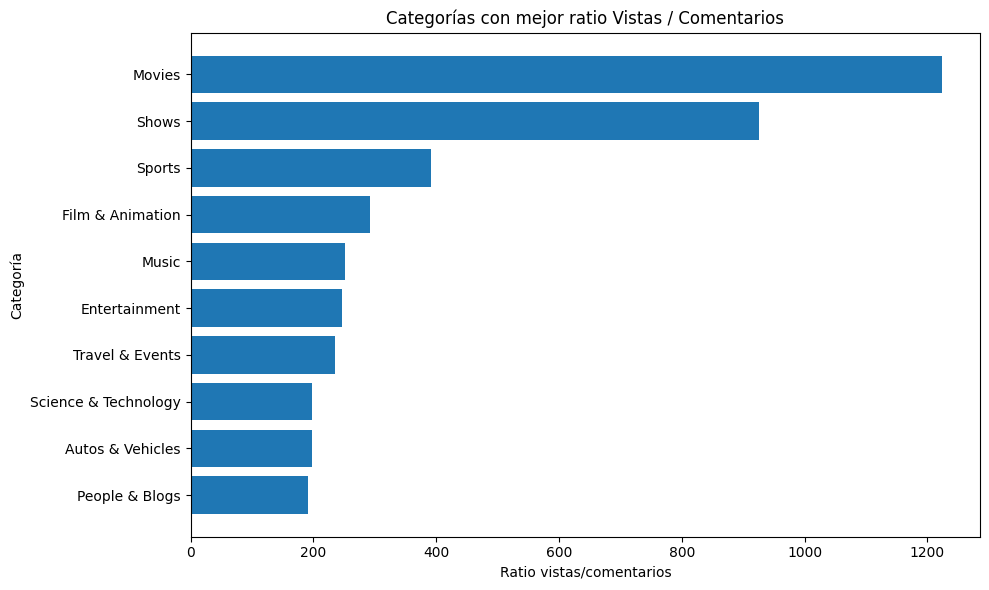

In [58]:
# Visualización del requerimiento 4 
top_req4 = req4_ratio_categoria.sort_values('views_comments_ratio', ascending=False).head(10).sort_values('views_comments_ratio') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_req4['category_title'], top_req4['views_comments_ratio']) 
plt.title('Categorías con mejor ratio Vistas / Comentarios') 
plt.xlabel('Ratio vistas/comentarios') 
plt.ylabel('Categoría') 
plt.tight_layout() 
plt.show()

In [59]:
# Requerimiento 5: Volumen de videos en tendencia a lo largo del tiempo 
req5_videos_tiempo = videos_clean.groupby('trending_date_dt').size().reset_index(name='cantidad_videos') 
req5_videos_tiempo.head()

,trending_date_dt,cantidad_videos
0,2017-11-14,200
1,2017-11-15,200
2,2017-11-16,200
3,2017-11-17,200
4,2017-11-18,200


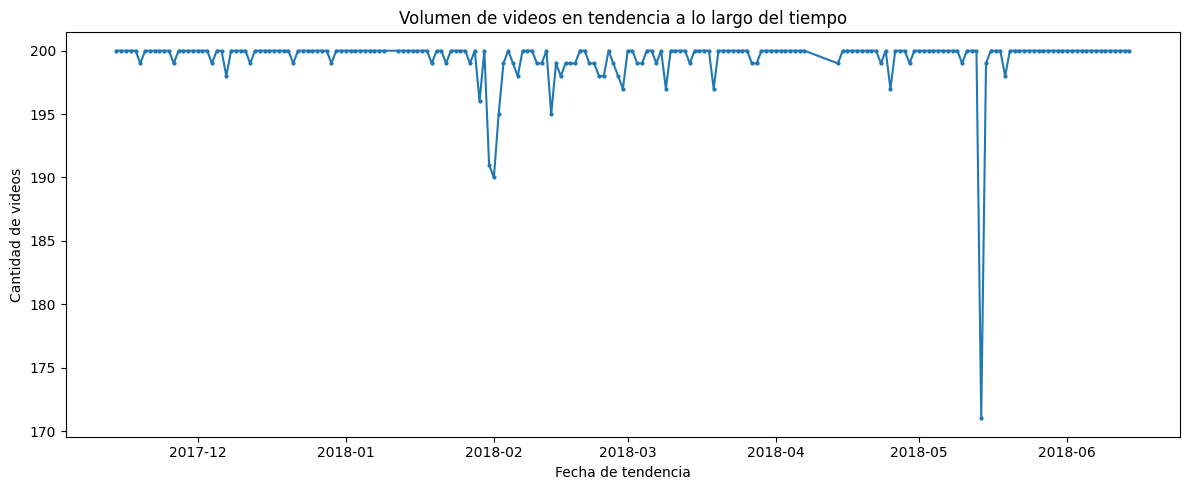

In [60]:
# Visualización del requerimiento 5 
plt.figure(figsize=(12, 5)) 
plt.plot(req5_videos_tiempo['trending_date_dt'], req5_videos_tiempo['cantidad_videos'], marker='o', markersize=2) 
plt.title('Volumen de videos en tendencia a lo largo del tiempo') 
plt.xlabel('Fecha de tendencia') 
plt.ylabel('Cantidad de videos') 
plt.tight_layout() 
plt.show()

In [61]:
# Requerimiento 6: Canales más frecuentes 
req6_canales = videos_clean['channel_title'].value_counts().reset_index() 
req6_canales.columns = ['channel_title', 'cantidad_apariciones'] 
req6_canales.head(10)

,channel_title,cantidad_apariciones
0,SET India,192
1,MSNBC,189
2,FBE,188
3,The Young Turks,186
4,REACT,183
5,VikatanTV,182
6,CNN,182
7,The Late Show with Stephen Colbert,172
8,RadaanMedia,168
9,ARY Digital,168


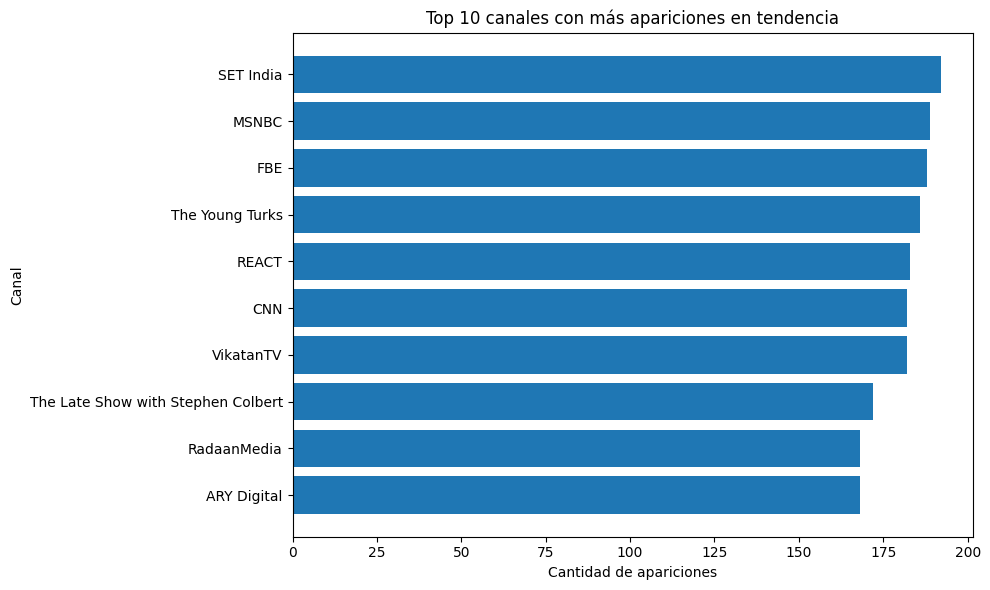

In [62]:
# Visualización de canales más frecuentes 
top_req6 = req6_canales.head(10).sort_values('cantidad_apariciones') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_req6['channel_title'], top_req6['cantidad_apariciones']) 
plt.title('Top 10 canales con más apariciones en tendencia') 
plt.xlabel('Cantidad de apariciones') 
plt.ylabel('Canal') 
plt.tight_layout() 
plt.show()

In [63]:
# Canales con menor frecuencia

canales_menor_frecuencia = req6_canales[req6_canales['cantidad_apariciones'] == 1]

print('Cantidad de canales que aparecen una sola vez:', canales_menor_frecuencia.shape[0])
canales_menor_frecuencia.head(10)

Cantidad de canales que aparecen una sola vez: 1694


,channel_title,cantidad_apariciones
3382,DKDKTV,1
3383,BasVEVO,1
3384,ኤርትራዊነት,1
3385,VOA Tiếng Việt,1
3386,tbs 시민의 방송,1
3387,GLP TV,1
3388,Straits Times,1
3389,FIBA3x3,1
3390,Weird World,1
3391,Household Hacker,1


In [64]:
# Requerimiento 7: Vistas, likes y dislikes por estado 
req7_estado = videos_clean.groupby('state').agg( 
    total_views=('views', 'sum'), 
    total_likes=('likes', 'sum'), 
    total_dislikes=('dislikes', 'sum'), 
    cantidad_videos=('video_id', 'count') 
).reset_index() 

req7_estado.sort_values('total_views', ascending=False)

,state,total_views,total_likes,total_dislikes,cantidad_videos
6,Nova Scotia,3908374167,134322361,7322786,3113
1,British Columbia,3900526242,148622590,6825012,3196
0,Alberta,3888860952,135427475,7759834,3209
5,Northwest Territories,3741698820,137867862,6912816,3140
9,Prince Edward Island,3737800298,114561446,6982402,3141
8,Ontario,3733666817,125585143,6578918,3156
3,New Brunswick,3513128479,122154056,5477339,3131
12,Yukon,3498078837,117762044,6114702,3159
2,Manitoba,3435091655,118586523,5743359,3123
10,Quebec,3431091134,123796800,5325817,3247


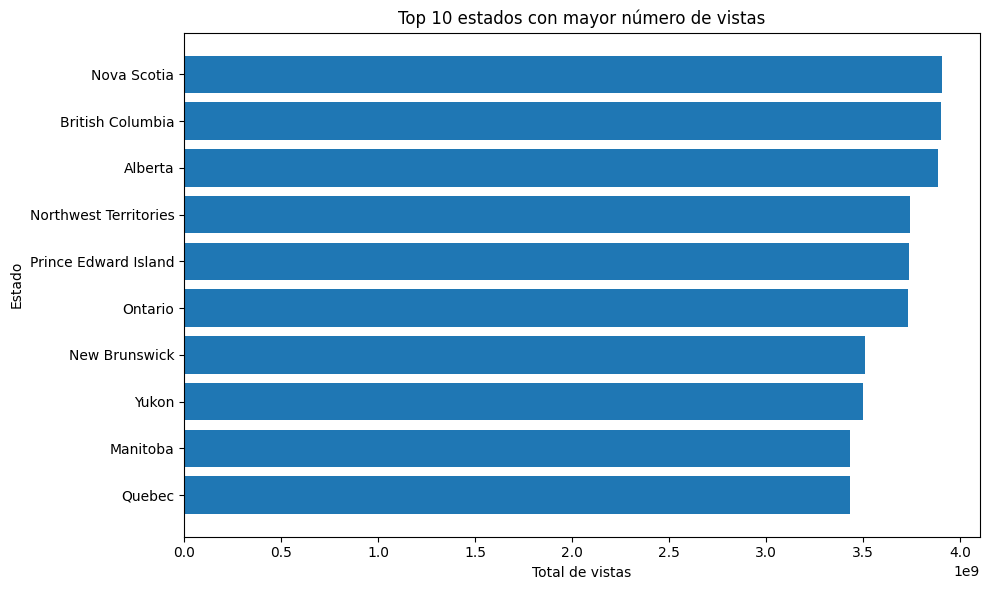

In [65]:
# Visualización de estados con mayor número de vistas 
top_estado_views = req7_estado.sort_values('total_views', ascending=False).head(10).sort_values('total_views') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_estado_views['state'], top_estado_views['total_views']) 
plt.title('Top 10 estados con mayor número de vistas') 
plt.xlabel('Total de vistas') 
plt.ylabel('Estado') 
plt.tight_layout() 
plt.show()

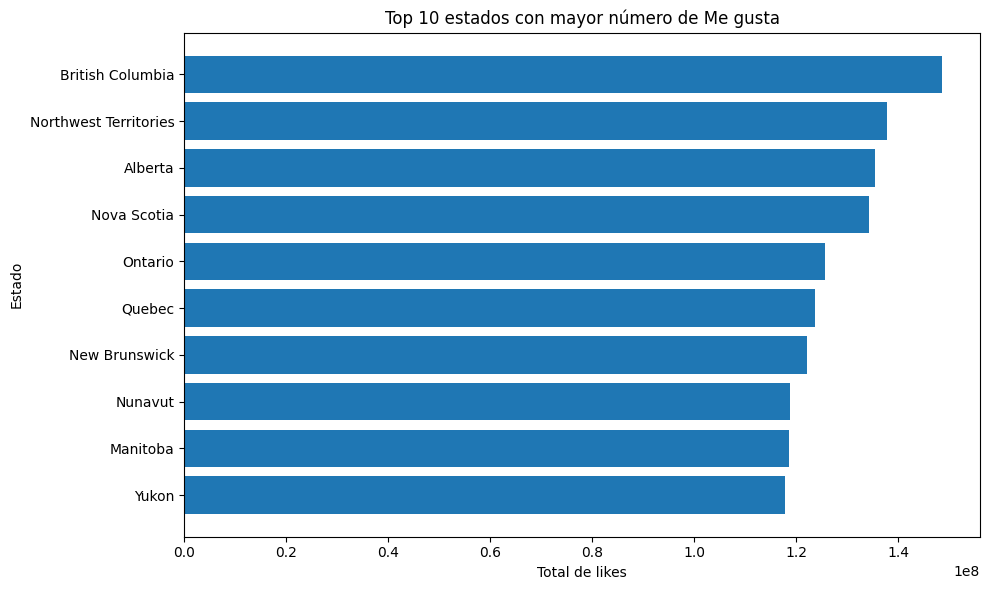

In [66]:
# Visualización de estados con mayor número de likes 
top_estado_likes = req7_estado.sort_values('total_likes', ascending=False).head(10).sort_values('total_likes') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_estado_likes['state'], top_estado_likes['total_likes']) 
plt.title('Top 10 estados con mayor número de Me gusta') 
plt.xlabel('Total de likes') 
plt.ylabel('Estado')
plt.tight_layout()
plt.show()

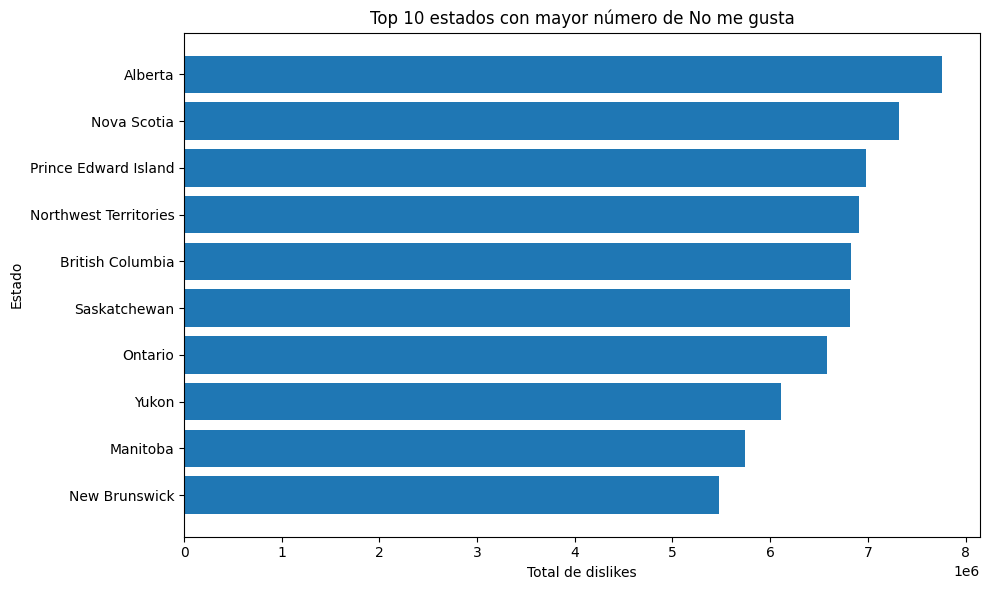

In [67]:
# Visualización de estados con mayor número de dislikes 
top_estado_dislikes = req7_estado.sort_values('total_dislikes', ascending=False).head(10).sort_values('total_dislikes')
plt.figure(figsize=(10, 6))
plt.barh(top_estado_dislikes['state'], top_estado_dislikes['total_dislikes']) 
plt.title('Top 10 estados con mayor número de No me gusta')
plt.xlabel('Total de dislikes') 
plt.ylabel('Estado')
plt.tight_layout() 
plt.show()

In [68]:
# Requerimiento 8: Relación entre comentarios e indicadores de aceptación 
req8_corr = videos_clean[['comment_count', 'likes', 'dislikes', 'views', 'like_dislike_ratio']].corr() 
req8_corr

,comment_count,likes,dislikes,views,like_dislike_ratio
comment_count,1.00,0.84,0.64,0.69,0.02
likes,0.84,1.00,0.46,0.83,0.06
dislikes,0.64,0.46,1.00,0.56,-0.05
views,0.69,0.83,0.56,1.00,-0.05
like_dislike_ratio,0.02,0.06,-0.05,-0.05,1.00


In [69]:
# Tabla de videos con más comentarios y su ratio likes/dislikes 
req8_top_comentarios = videos_clean[[ 
    'title',
    'channel_title', 
    'category_title', 
    'comment_count', 
    'likes', 
    'dislikes', 
    'like_dislike_ratio' 
]].sort_values('comment_count', ascending=False).head(10) 

req8_top_comentarios

,title,channel_title,category_title,comment_count,likes,dislikes,like_dislike_ratio
36453,BTS (방탄소년단) 'FAKE LOVE' Official MV,ibighit,Music,1114800,5053338,165854,30.47
36153,BTS (방탄소년단) 'FAKE LOVE' Official MV,ibighit,Music,1084435,4924056,156026,31.56
35900,BTS (방탄소년단) 'FAKE LOVE' Official MV,ibighit,Music,1040912,4750254,141966,33.46
35685,BTS (방탄소년단) 'FAKE LOVE' Official MV,ibighit,Music,905912,4470888,119046,37.56
4996,YouTube Rewind: The Shape of 2017 | #YouTubeRewind,YouTube Spotlight,Entertainment,827755,2251826,1127811,2.00
5900,YouTube Rewind: The Shape of 2017 | #YouTubeRewind,YouTube Spotlight,Entertainment,817582,3014479,1602383,1.88
5623,YouTube Rewind: The Shape of 2017 | #YouTubeRewind,YouTube Spotlight,Entertainment,807558,2912715,1545018,1.89
5398,YouTube Rewind: The Shape of 2017 | #YouTubeRewind,YouTube Spotlight,Entertainment,787174,2811217,1470387,1.91
4795,YouTube Rewind: The Shape of 2017 | #YouTubeRewind,YouTube Spotlight,Entertainment,702784,1891822,884963,2.14
35515,BTS (방탄소년단) 'FAKE LOVE' Official MV,ibighit,Music,692311,3880074,72707,53.37


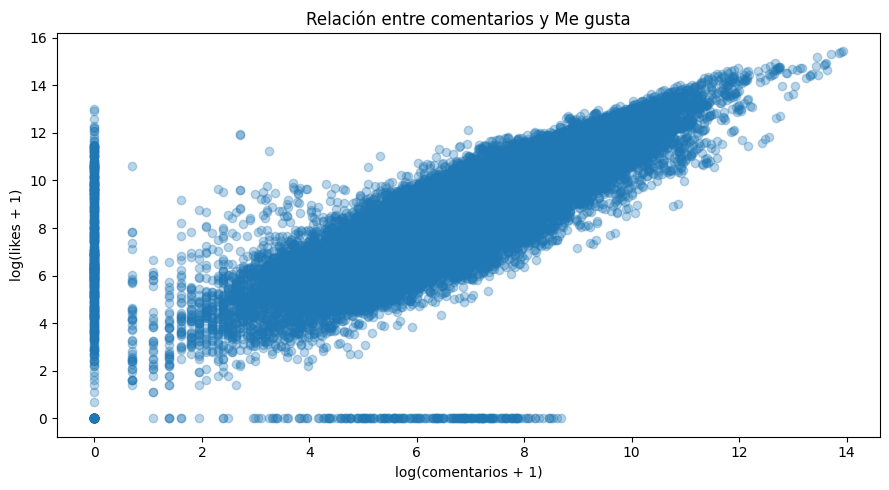

In [70]:
# Visualización del requerimiento 8 
plt.figure(figsize=(9, 5)) 
plt.scatter(np.log1p(videos_clean['comment_count']), np.log1p(videos_clean['likes']), alpha=0.3) 
plt.title('Relación entre comentarios y Me gusta') 
plt.xlabel('log(comentarios + 1)') 
plt.ylabel('log(likes + 1)')
plt.tight_layout() 
plt.show()

In [71]:
# Requerimiento 9: Correlación de variables numéricas con views 
variables_modelo_inicial = [ 
    'views', 
    'likes', 
    'dislikes', 
    'comment_count', 
    'days_to_trend', 
    'like_dislike_ratio', 
    'like_rate', 
    'dislike_rate', 
    'comment_rate', 
    'tag_count', 
    'title_length' 
] 

corr_views = videos_clean[variables_modelo_inicial].corr()['views'].sort_values(ascending=False).reset_index() 
corr_views.columns = ['variable', 'correlacion_con_views'] 
corr_views

,variable,correlacion_con_views
0,views,1.00
1,likes,0.83
2,comment_count,0.69
3,dislikes,0.56
4,dislike_rate,0.04
5,like_rate,0.01
6,tag_count,0.00
7,days_to_trend,0.00
8,title_length,-0.01
9,like_dislike_ratio,-0.05


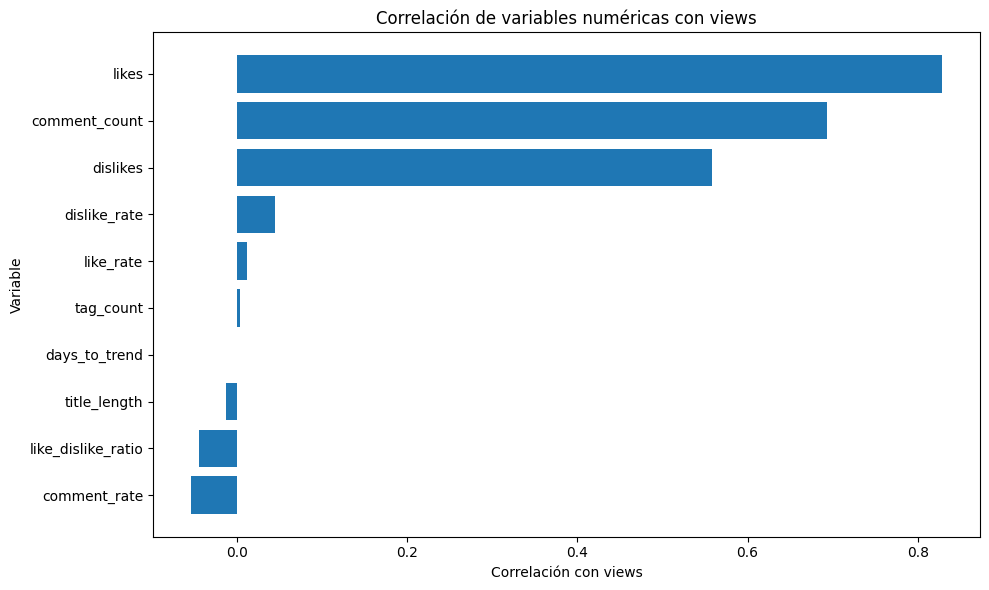

In [72]:
# Visualización del requerimiento 9

corr_plot = corr_views[corr_views['variable'] != 'views'].sort_values('correlacion_con_views')

plt.figure(figsize=(10, 6))
plt.barh(corr_plot['variable'], corr_plot['correlacion_con_views'])
plt.title('Correlación de variables numéricas con views')
plt.xlabel('Correlación con views')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

In [73]:
# 3.4.1 Selección de la técnica de modelado 
# # Importación de librerías para modelado y evaluación 
from sklearn.model_selection import train_test_split 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler 
from sklearn.pipeline import Pipeline 
from sklearn.dummy import DummyRegressor 
from sklearn.linear_model import Ridge 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 

print('Librerías de modelado importadas correctamente.') 
print('Dataset disponible para modelado:', 'videos_clean' in globals()) 
print('Dimensión del dataset final:', videos_clean.shape)

Librerías de modelado importadas correctamente.
Dataset disponible para modelado: True
Dimensión del dataset final: (40881, 39)


Resumen de la variable views:


,count,mean,std,min,25%,50%,75%,max
views,"40,881.00","1,147,035.91","3,390,913.02",733.00,"143,902.00","371,204.00","963,302.00","137,843,120.00"
log_views,"40,881.00",12.81,1.51,6.60,11.88,12.82,13.78,18.74


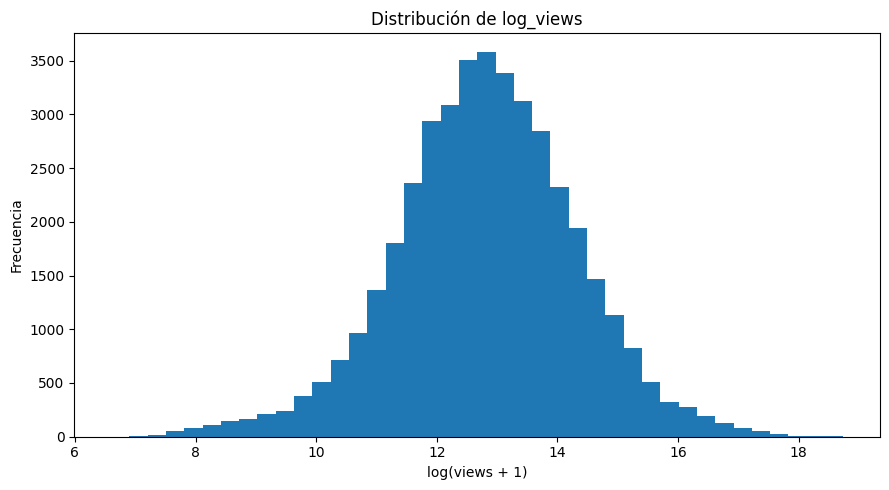

In [74]:
# Revisión de la variable dependiente views y su transformación logarítmica 
if 'log_views' not in videos_clean.columns: videos_clean['log_views'] = np.log1p(videos_clean['views']) 
print('Resumen de la variable views:') 
display(videos_clean[['views', 'log_views']].describe().T) 
plt.figure(figsize=(9, 5)) 
plt.hist(videos_clean['log_views'], bins=40) 
plt.title('Distribución de log_views') 
plt.xlabel('log(views + 1)') 
plt.ylabel('Frecuencia') 
plt.tight_layout() 
plt.show()

In [76]:
# Definición de la variable dependiente 
target_original = 'views' 
target_modelo = 'log_views' 
print('Variable dependiente original:', target_original) 
print('Variable usada para entrenamiento:', target_modelo)

Variable dependiente original: views
Variable usada para entrenamiento: log_views


In [77]:
# Definición de variables independientes 
variables_numericas_modelo = [ 
    'log_likes', 
    'log_dislikes', 
    'log_comment_count', 
    'days_to_trend', 
    'like_dislike_ratio', 
    'tag_count', 
    'title_length', 
    'description_length' 
] 

variables_categoricas_modelo = [ 
    'category_title', 
    'state', 
    'comments_disabled', 
    'ratings_disabled', 
    'video_error_or_removed', 
    'trending_weekday', 
    'is_weekend' 
]

variables_modelo = variables_numericas_modelo + variables_categoricas_modelo 
tabla_variables_modelo = pd.DataFrame({ 
    'Variable': variables_modelo, 
    'Tipo': ['Numérica'] * len(variables_numericas_modelo) + ['Categórica/Booleana'] * len(variables_categoricas_modelo) 
}) 

tabla_variables_modelo

,Variable,Tipo
0,log_likes,Numérica
1,log_dislikes,Numérica
2,log_comment_count,Numérica
3,days_to_trend,Numérica
4,like_dislike_ratio,Numérica
5,tag_count,Numérica
6,title_length,Numérica
7,description_length,Numérica
8,category_title,Categórica/Booleana
9,state,Categórica/Booleana


In [78]:
# Creación del dataset de modelado 
columnas_modelado = variables_modelo + [target_original, target_modelo] 
datos_modelo = videos_clean[columnas_modelado].copy() 
datos_modelo = datos_modelo.replace([np.inf, -np.inf], np.nan) 
datos_modelo = datos_modelo.dropna() 

print('Dimensión del dataset para modelado:') 
print(f'Filas: {datos_modelo.shape[0]:,}') 
print(f'Columnas: {datos_modelo.shape[1]}') 
datos_modelo.head()

Dimensión del dataset para modelado:
Filas: 40,881
Columnas: 17


,log_likes,log_dislikes,log_comment_count,days_to_trend,like_dislike_ratio,tag_count,title_length,description_length,category_title,state,comments_disabled,ratings_disabled,video_error_or_removed,trending_weekday,is_weekend,views,log_views
0,13.58,10.68,11.74,3,18.13,6,42,594,Music,Manitoba,False,False,False,Tuesday,False,17158579,16.66
1,11.76,7.43,9.48,0,75.66,11,29,704,Comedy,British Columbia,False,False,False,Tuesday,False,1014651,13.83
2,11.89,8.58,9.01,1,27.35,23,53,1177,Comedy,New Brunswick,False,False,False,Tuesday,False,3191434,14.98
3,11.79,7.60,9.77,1,66.45,14,24,636,Entertainment,Saskatchewan,False,False,False,Tuesday,False,2095828,14.56
4,14.31,9.96,11.35,4,77.51,10,43,1250,Music,Alberta,False,False,False,Tuesday,False,33523622,17.33


In [79]:
# Separación de variables independientes y dependiente 
X = datos_modelo[variables_modelo] 
y = datos_modelo[target_modelo] 
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42 ) 
print('Tamaño del conjunto de entrenamiento:') 
print('X_train:', X_train.shape) 
print('y_train:', y_train.shape) 
print('\nTamaño del conjunto de prueba:') 
print('X_test:', X_test.shape) 
print('y_test:', y_test.shape) 

Tamaño del conjunto de entrenamiento:
X_train: (32704, 15)
y_train: (32704,)

Tamaño del conjunto de prueba:
X_test: (8177, 15)
y_test: (8177,)


In [81]:
# Definición del preprocesamiento 
preprocesamiento = ColumnTransformer( transformers=[ ('num', StandardScaler(), variables_numericas_modelo), ('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas_modelo) ] ) 
print('Preprocesamiento definido correctamente.') 
for i in range(len(variables_numericas_modelo)): 
    print(f'Variable numérica {i+1}: {variables_numericas_modelo[i]}')
for i in range(len(variables_categoricas_modelo)): 
    print(f'Variable categórica/booleana {i+1}: {variables_categoricas_modelo[i]}')


Preprocesamiento definido correctamente.
Variable numérica 1: log_likes
Variable numérica 2: log_dislikes
Variable numérica 3: log_comment_count
Variable numérica 4: days_to_trend
Variable numérica 5: like_dislike_ratio
Variable numérica 6: tag_count
Variable numérica 7: title_length
Variable numérica 8: description_length
Variable categórica/booleana 1: category_title
Variable categórica/booleana 2: state
Variable categórica/booleana 3: comments_disabled
Variable categórica/booleana 4: ratings_disabled
Variable categórica/booleana 5: video_error_or_removed
Variable categórica/booleana 6: trending_weekday
Variable categórica/booleana 7: is_weekend


In [82]:
# Construcción de modelos mediante pipelines

modelos = {
    'Baseline': Pipeline(steps=[
        ('preprocess', preprocesamiento),
        ('model', DummyRegressor(strategy='mean'))
    ]),
    
    'Ridge Regression': Pipeline(steps=[
        ('preprocess', preprocesamiento),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Random Forest': Pipeline(steps=[
        ('preprocess', preprocesamiento),
        ('model', RandomForestRegressor(
            n_estimators=80,
            max_depth=12,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

print('Modelos definidos:')
for nombre in modelos.keys():
    print('-', nombre)

Modelos definidos:
- Baseline
- Ridge Regression
- Random Forest


In [83]:
# Entrenamiento de los modelos 
modelos_entrenados = {} 
for nombre, modelo in modelos.items(): 
    print(f'Entrenando modelo: {nombre}') 
    modelo.fit(X_train, y_train) 
    modelos_entrenados[nombre] = modelo 
    
print('\nTodos los modelos fueron entrenados correctamente.')

Entrenando modelo: Baseline
Entrenando modelo: Ridge Regression
Entrenando modelo: Random Forest

Todos los modelos fueron entrenados correctamente.


In [84]:
# Evaluación de los modelos

resultados_modelos = []
predicciones_modelos = {}

y_test_original = np.expm1(y_test)

for nombre, modelo in modelos_entrenados.items():
    y_pred_log = modelo.predict(X_test)
    y_pred_original = np.expm1(y_pred_log)
    
    # Evitar predicciones negativas por seguridad
    y_pred_original = np.maximum(0, y_pred_original)
    
    mae = mean_absolute_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    r2_original = r2_score(y_test_original, y_pred_original)
    r2_log = r2_score(y_test, y_pred_log)
    
    resultados_modelos.append([
        nombre,
        mae,
        rmse,
        r2_original,
        r2_log
    ])
    
    predicciones_modelos[nombre] = y_pred_original

resultados_modelos = pd.DataFrame(resultados_modelos, columns=[
    'Modelo',
    'MAE',
    'RMSE',
    'R2_original',
    'R2_log'
])

resultados_modelos.sort_values('RMSE')

,Modelo,MAE,RMSE,R2_original,R2_log
2,Random Forest,"353,175.65","1,069,803.90",0.90,0.89
1,Ridge Regression,"513,979.26","2,017,886.23",0.63,0.84
0,Baseline,"997,074.99","3,413,208.61",-0.06,-0.00


In [85]:
# Selección del mejor modelo según RMSE 
mejor_modelo_nombre = resultados_modelos.sort_values('RMSE').iloc[0]['Modelo'] 
mejor_modelo = modelos_entrenados[mejor_modelo_nombre] 
mejores_metricas = resultados_modelos[resultados_modelos['Modelo'] == mejor_modelo_nombre] 
print('Mejor modelo según RMSE:', mejor_modelo_nombre) 
display(mejores_metricas)

Mejor modelo según RMSE: Random Forest


,Modelo,MAE,RMSE,R2_original,R2_log
2,Random Forest,"353,175.65","1,069,803.90",0.90,0.89


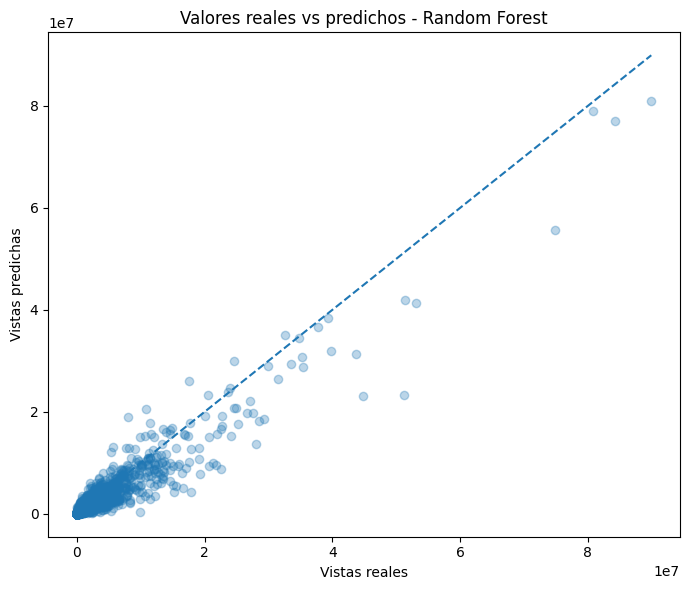

In [86]:
# Gráfico de valores reales vs predichos del mejor modelo 
y_pred_mejor = predicciones_modelos[mejor_modelo_nombre] 
plt.figure(figsize=(7, 6)) 
plt.scatter(y_test_original, y_pred_mejor, alpha=0.3) 
limite_max = max(y_test_original.max(), y_pred_mejor.max()) 
plt.plot([0, limite_max], [0, limite_max], linestyle='--') 
plt.title(f'Valores reales vs predichos - {mejor_modelo_nombre}') 
plt.xlabel('Vistas reales') 
plt.ylabel('Vistas predichas') 
plt.tight_layout() 
plt.show()

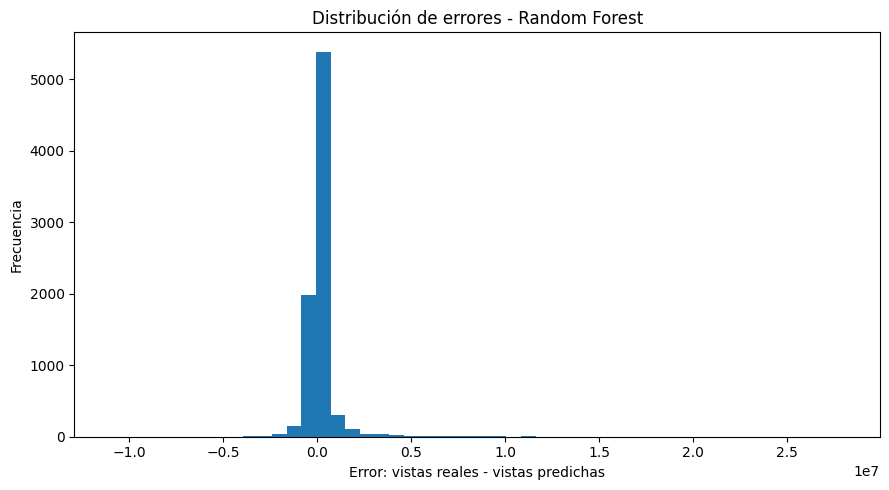

In [87]:
# Distribución de errores del mejor modelo 
errores = y_test_original - y_pred_mejor 
plt.figure(figsize=(9, 5)) 
plt.hist(errores, bins=50) 
plt.title(f'Distribución de errores - {mejor_modelo_nombre}') 
plt.xlabel('Error: vistas reales - vistas predichas') 
plt.ylabel('Frecuencia') 
plt.tight_layout() 
plt.show()

In [91]:
# Generación automática de interpretación breve con los resultados obtenidos 
fila_mejor = resultados_modelos.sort_values('RMSE').iloc[0] 
interpretacion_modelo = f"""El modelo con mejor desempeño fue {fila_mejor['Modelo']}, ya que obtuvo el menor RMSE entre los modelos evaluados. Sus métricas fueron:
\tMAE = {fila_mejor['MAE']:,.2f}, 
\tRMSE = {fila_mejor['RMSE']:,.2f}, 
\tR² en escala original = {fila_mejor['R2_original']:.4f} y 
\tR² en escala logarítmica = {fila_mejor['R2_log']:.4f}. 
Esto indica que el modelo logra capturar una parte importante del comportamiento de la variable views, aunque todavía puede presentar 
errores debido a la naturaleza variable y viral de los contenidos de YouTube. """ 

print(interpretacion_modelo)

El modelo con mejor desempeño fue Random Forest, ya que obtuvo el menor RMSE entre los modelos evaluados. Sus métricas fueron:
	MAE = 353,175.65, 
	RMSE = 1,069,803.90, 
	R² en escala original = 0.8961 y 
	R² en escala logarítmica = 0.8875. 
Esto indica que el modelo logra capturar una parte importante del comportamiento de la variable views, aunque todavía puede presentar 
errores debido a la naturaleza variable y viral de los contenidos de YouTube. 


In [92]:
# Importancia de variables del modelo Random Forest 
rf_model = modelos_entrenados['Random Forest'] 
feature_names = rf_model.named_steps['preprocess'].get_feature_names_out() 
importances = rf_model.named_steps['model'].feature_importances_ 
importancia_variables = pd.DataFrame({ 'variable': feature_names, 'importancia': importances }).sort_values('importancia', ascending=False) 
importancia_variables.head(15)

,variable,importancia
1,num__log_dislikes,0.76
0,num__log_likes,0.12
3,num__days_to_trend,0.02
6,num__title_length,0.01
2,num__log_comment_count,0.01
40,cat__ratings_disabled_False,0.01
7,num__description_length,0.01
5,num__tag_count,0.01
23,cat__category_title_Sports,0.01
4,num__like_dislike_ratio,0.01


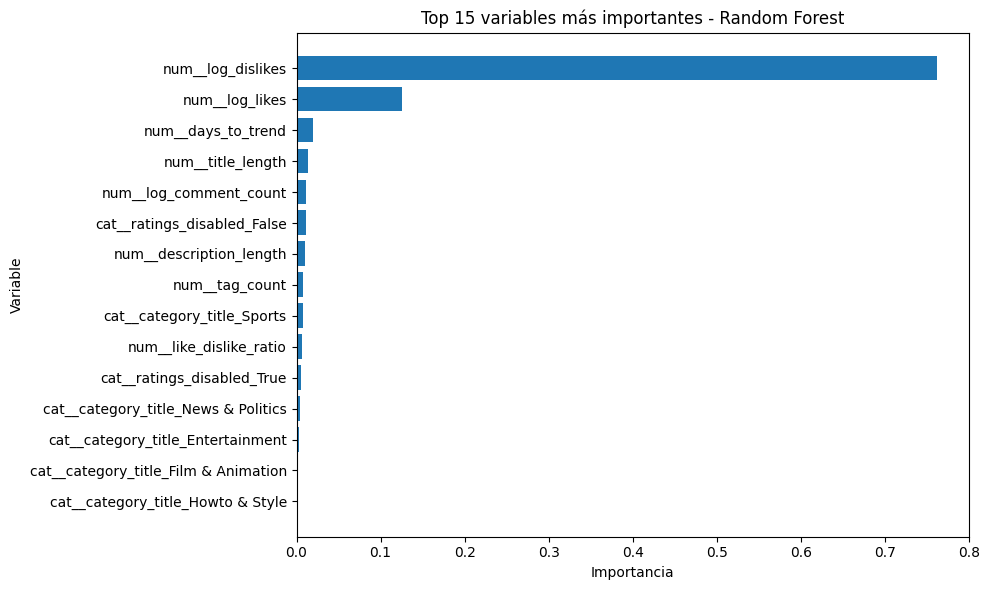

In [93]:
# Visualización de importancia de variables 
top_importancias = importancia_variables.head(15).sort_values('importancia') 
plt.figure(figsize=(10, 6)) 
plt.barh(top_importancias['variable'], top_importancias['importancia']) 
plt.title('Top 15 variables más importantes - Random Forest') 
plt.xlabel('Importancia') 
plt.ylabel('Variable') 
plt.tight_layout() 
plt.show()